# Calibrator Data Investigations

A notebook to look at calibrator data and investigate peculiarities.

In [1]:
import numpy as np
import statistics as stat
import scipy
from matplotlib import pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
# import PrizmCalibration as cl # this module is missing dependencies
# from gsm_data import GSMData, get_desired_frequencies
# from data_prep import DataPrep

# For reloading the module (useful for debugging)
import data
import data_prep
try:
    reload(data) # dependent module (imported in data_prep)
    reload(data_prep)
    from data_prep import DataPrep
except:
    from importlib import reload
    reload(data) # dependent module (imported in data_prep)
    reload(data_prep)
    from data_prep import DataPrep

from helper_functions import *
import data_utils
reload(data_utils)
import data_utils as du

In [2]:
# calibration_type = 'GSM'

# Frequency array and cutoffs
freqarr, freqstep = np.linspace(0,250,4096,retstep=True) # Based on number of frequency channels of the antenna
minfreq = 30
maxfreq = 200 
minfreqarg = int(minfreq/freqstep)
maxfreqarg = int(maxfreq/freqstep)

## Short Calibrator Investigation

### 2021, 100MHz, NS -- USED FOR CALIBRATOR FLAGGING TESTING

In [3]:
# 2021, 100 MHz, NS
year = '2021'
instrument = '100MHz'
channel = 'NS'

#### With Flagging

In [ ]:
# Need to load from the metadatabase
dataprep = DataPrep(instrument, channel, year)

In [5]:
# return short calibrator data
masked_data_lst, masked_data = dataprep.get_flagged_calibrator_data(partition='short')
unmasked_data = dataprep.shorts_data

print(masked_data.shape)
print(unmasked_data.shape)
print(np.all(dataprep.calib_mask_dict['short']==True)) # False = the mask did something!

(3294, 4096)
(4013, 4096)
False


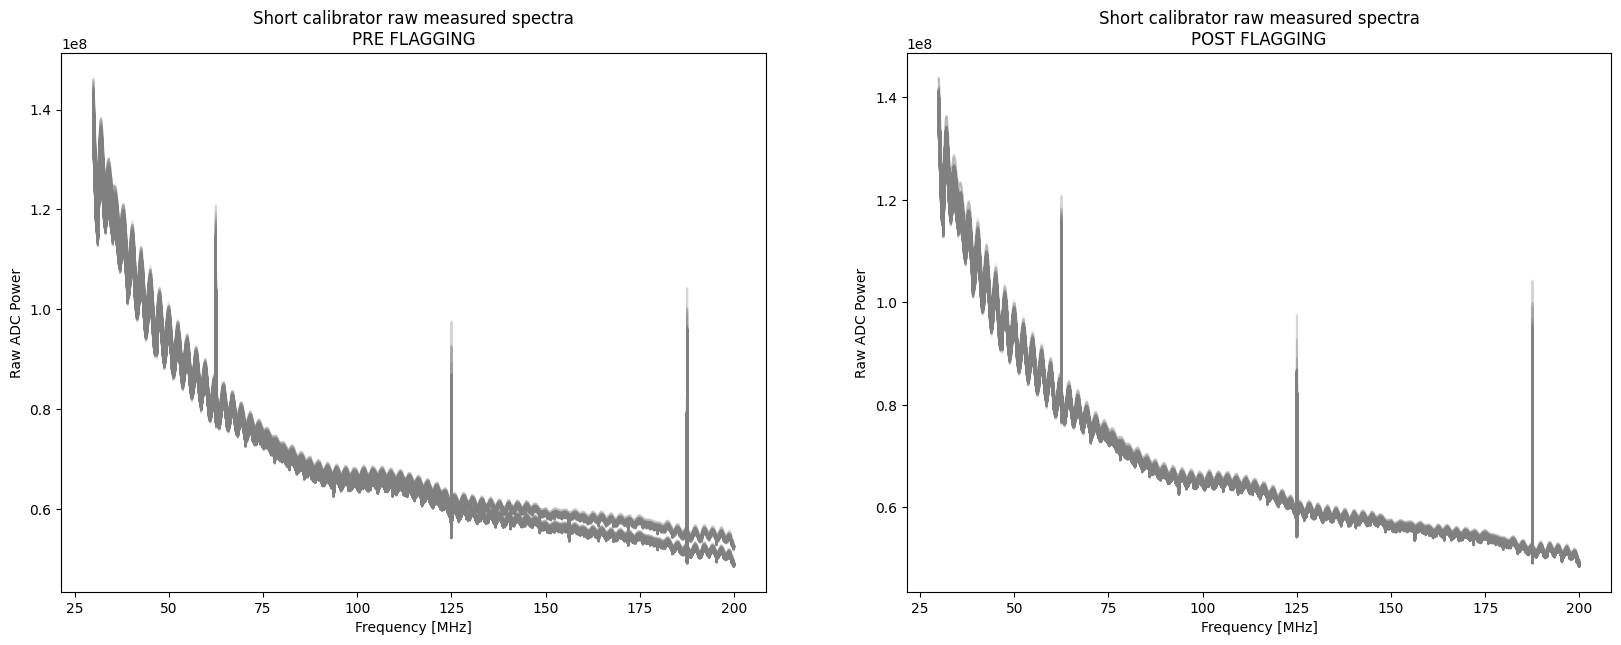

In [6]:
# plot the masked short data to see if the odd spectra are still there

# plt.subplots(nrows=1,ncols=2,figsize=(20,5))

plt.figure(figsize=(20,7))
plt.subplot(121)
for i in range(unmasked_data.shape[0]):
    plt.plot(freqarr[minfreqarg:maxfreqarg],unmasked_data[i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)

plt.xlabel('Frequency [MHz]')
plt.ylabel('Raw ADC Power')
plt.title('Short calibrator raw measured spectra\nPRE FLAGGING')

plt.subplot(122)
for i in range(masked_data.shape[0]):
    plt.plot(freqarr[minfreqarg:maxfreqarg],masked_data[i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)

plt.xlabel('Frequency [MHz]')
plt.ylabel('Raw ADC Power')
plt.title('Short calibrator raw measured spectra\nPOST FLAGGING')
plt.show()

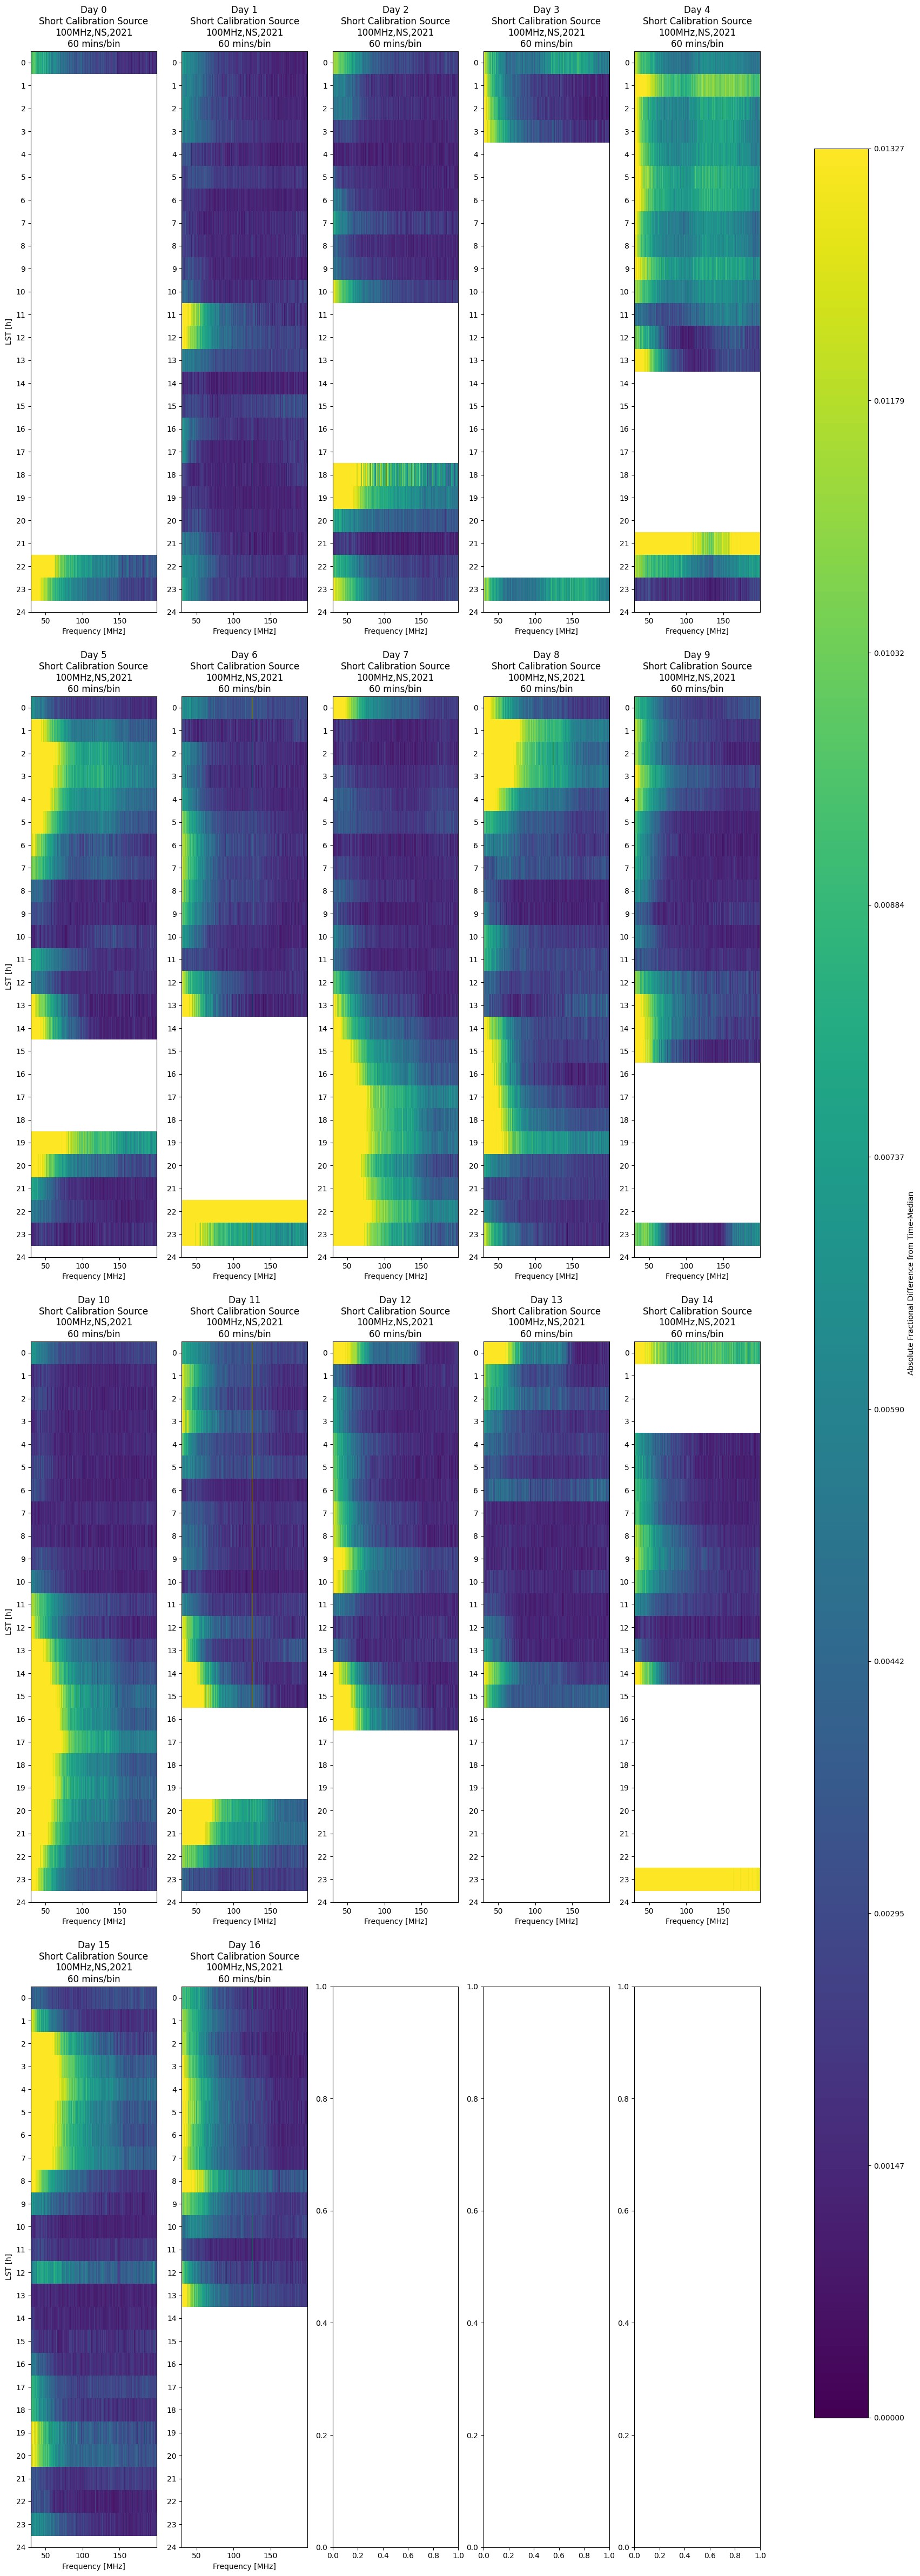

In [11]:
# Waterfall plot of short measured spectra -- POST FLAGGING! LOOKS GOOD!!!!
reload(du)
du.time_variation(masked_data,masked_data_lst,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='waterfall')

#### Adding Interpolation

In [12]:
# Need to load from the metadatabase
dataprep = DataPrep(instrument, channel, year)

Returning default mask
Returning default mask


In [13]:
print(dataprep.shorts.shape)
# print(np.any(np.isnan(dataprep.shorts)))
# print(dataprep.antenna.shape)
# print(dataprep.lst.shape)

nan_indices = []

for i in range(dataprep.shorts.shape[0]):
    if np.all(np.isnan(dataprep.shorts[i])):
        nan_indices.append(i)

nan_times = dataprep.lst[nan_indices]
# print(nan_indices)
print(nan_times,len(nan_times))

du.time_variation(dataprep.shorts,dataprep.lst,freqarr,source=r'Short',plot_type='waterfall',year=year,instrument=instrument,channel=channel)

(165328, 4096)
[15.84547319 15.84732573 15.84904903 ... 21.12765017 21.12945813
 21.13124047] 23126


ValueError: cannot convert float NaN to integer

<Figure size 2000x6000 with 21 Axes>

In [84]:
# Comparing to interpolation results back when we had no flagging
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
no_flag_data = du.load_all_data(filepath,instrument,channel,year,LoadAnt=True,LoadInterpCalib=True)
print(no_flag_data.keys())

dict_keys(['antdata', 'antlst', 'antsystime', 'shortdata_meas', 'shortlst', 'shortsystime', 'shortinterp', 'res50data_meas', 'res50lst', 'res50systime', 'res50interp', 'res100data_meas', 'res100lst', 'res100systime', 'res100interp'])


(165328, 4096)
False
(165328, 4096)
(165328,)


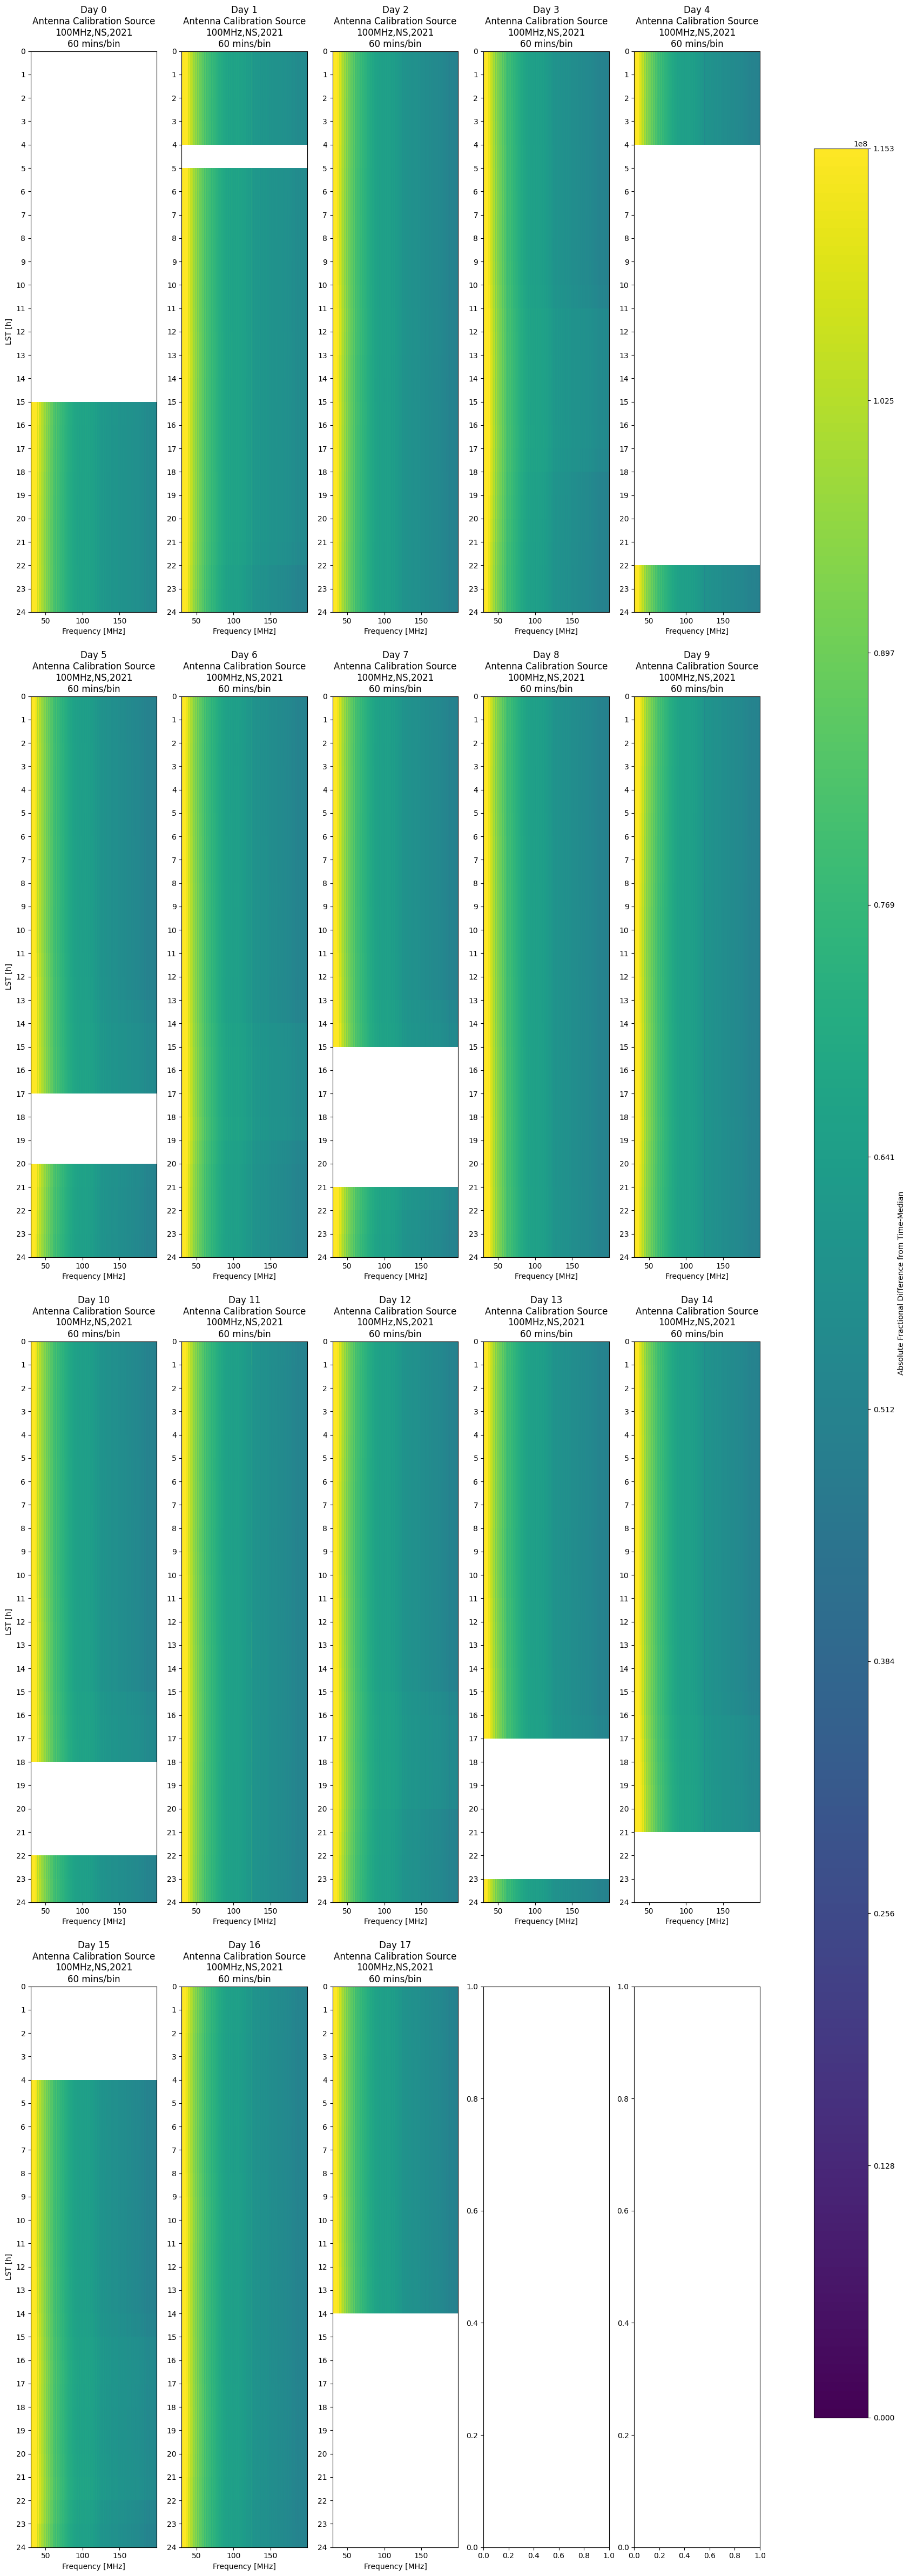

In [118]:
print(no_flag_data['shortinterp'].shape)
print(np.any(np.isnan(no_flag_data['shortinterp'])))
print(no_flag_data['antdata'].shape)
print(no_flag_data['antlst'].shape)

# du.waterfall_alldays(no_flag_data['shortinterp'],no_flag_data['antlst'],freqarr,source='Antenna',year=year,instrument=instrument,channel=channel)

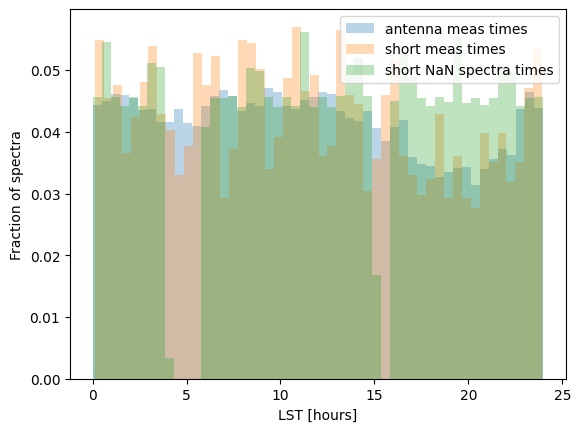

In [114]:
dbool = True
plt.hist(x=no_flag_data['antlst'],bins=50,label='antenna meas times',alpha=0.3,density=dbool)
plt.hist(x=dataprep.shorts_data_lst,bins=50,label='short meas times',alpha=0.3,density=dbool)
plt.hist(x=nan_times, bins=50,label='short NaN spectra times',alpha=0.3,density=dbool)

plt.xlabel('LST [hours]')
plt.ylabel('Fraction of spectra')
plt.legend()
plt.show()

719
9946
89.2430278884462 % of day 0 and 1 spectra are flagged


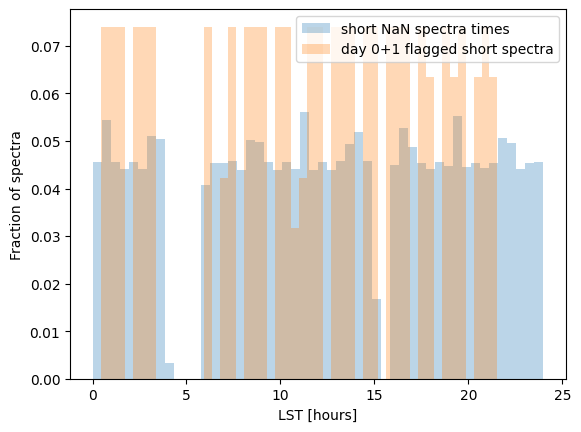

2


In [173]:
dbool = True # triggers density histograms (integrates to 1)
plt.hist(x=nan_times, bins=50,label='short NaN spectra times',alpha=0.3,density=dbool)
bad_data = dataprep.get_flagged_calibrator_data(partition='short',return_flagged=True)
# plt.hist(x=bad_data[0],bins=50,label='short flagged spectra times',alpha=0.3,density=dbool)
print(len(bad_data[0])) # number of flagged spectra
print(len(nan_times)) # number of nan interpolated spectra

lst_splitshort, data_splitshort = du.LST_days_split(dataprep.shorts_data_lst,dataprep.shorts_data)
day01_mask = dataprep.calib_mask_dict['short'][len(lst_splitshort[0]):len(np.concatenate(lst_splitshort[0:2]))]
plt.hist(x=lst_splitshort[1][~day01_mask],bins=50,label='day 0+1 flagged short spectra',alpha=0.3,density=dbool)
print(len(lst_splitshort[1][~day01_mask])/len(lst_splitshort[1])*100,
     '% of day 0 and 1 spectra are flagged')

plt.xlabel('LST [hours]')
plt.ylabel('Fraction of spectra')
plt.legend()
plt.show()

# Figuring out over how many days the remaining NaN short spectra are distributed
lst_splitshort, data_splitshort = du.LST_days_split(nan_times,dataprep.shorts[0:len(nan_times)])
print(len(lst_splitshort))

#### Without Flagging

In [5]:
# dataprep = DataPrep(instrument, channel, year)
'''Data has been saved, load in with load_all_data()'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
dataprep = du.load_all_data(filepath,instrument,channel,year,LoadAnt=True,LoadInterpCalib=False)
print(dataprep.keys())
short_mask = np.load(filepath+'shortdata_2021_100MHz_NS_mask.npy')

dict_keys(['antdata', 'antlst', 'antsystime', 'shortdata_meas', 'shortlst', 'shortsystime', 'res50data_meas', 'res50lst', 'res50systime', 'res100data_meas', 'res100lst', 'res100systime'])


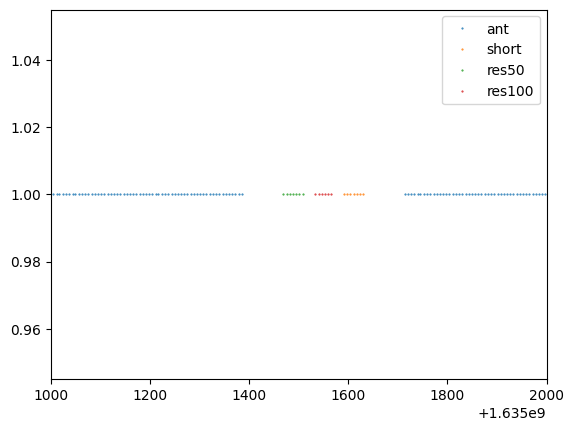

In [21]:
plt.plot(dataprep['antsystime'],[1]*len(dataprep['antsystime']),'.',label='ant',markersize=1,)
plt.plot(dataprep['shortsystime'],[1]*len(dataprep['shortsystime']),'.',label='short',markersize=1)
plt.plot(dataprep['res50systime'],[1]*len(dataprep['res50systime']),'.',label='res50',markersize=1)
plt.plot(dataprep['res100systime'],[1]*len(dataprep['res100systime']),'.',label='res100',markersize=1)
plt.legend()
plt.xlim(1.6350e9,1.635005e9)
plt.xlim(1.6350e9+1000,1.6350e9+2000)

plt.show()

In [6]:
print(dataprep['antdata'].shape) # checking that the NS here is the same as in Lisa's Analysis_pipeline code # CHECK

(165328, 4096)


KeyboardInterrupt: 

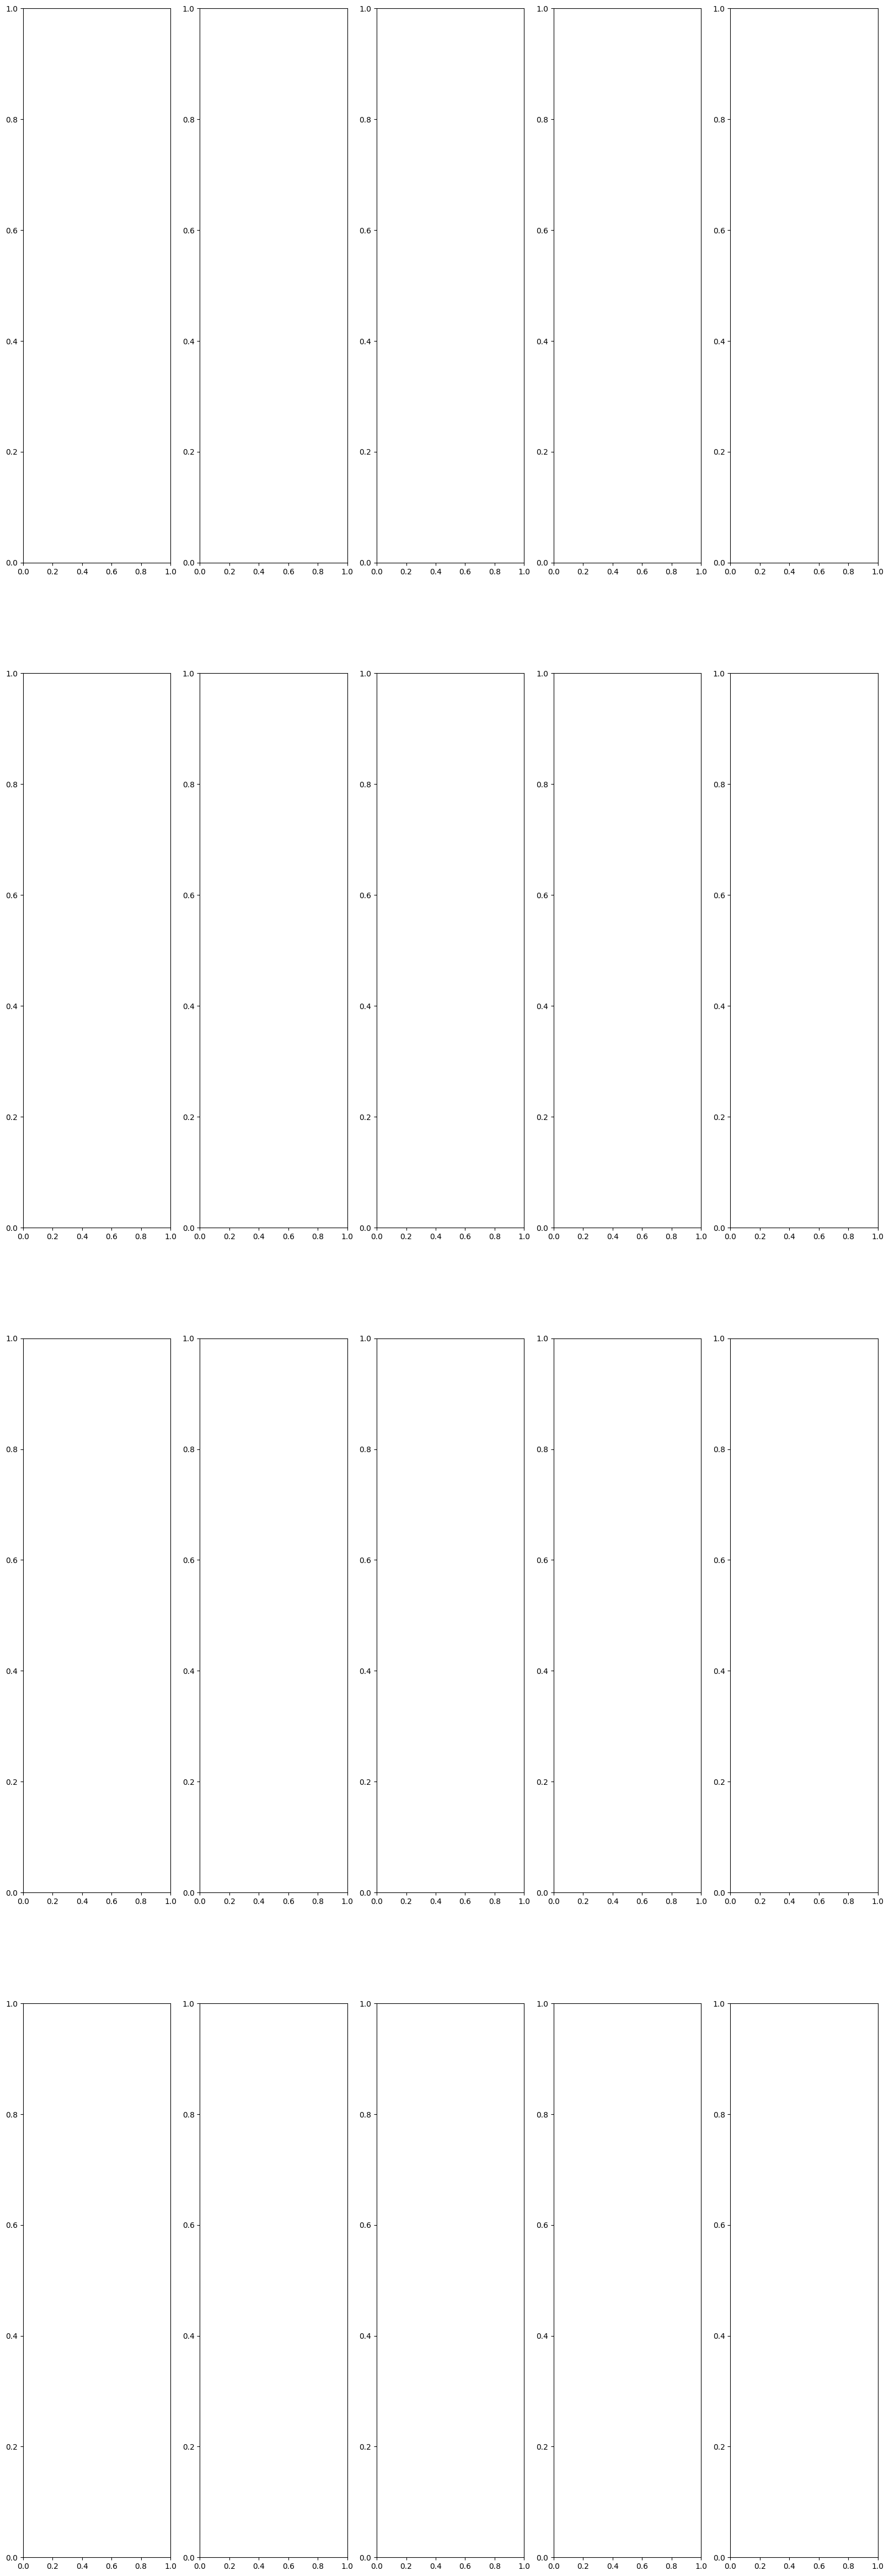

In [16]:
# Interpolated spectra waterfall plots

datashort = dataprep.shorts
lstshort = dataprep.lst

# waterfall_alldays(datashort,lstshort,freqarr,source='Short') # raw spectra

du.time_variation(datashort,lstshort,freqarr,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

In [63]:
# print(datashort_meas[short_mask].shape)
# print(np.concatenate((np.full((2,4096),np.nan),datashort_meas[short_mask])).shape,np.concatenate(([23,23.5],lstshort_meas[short_mask])).shape)

(3294, 4096)
(3296, 4096) (3296,)


In [34]:
# Antenna
# try:
#     datashort_meas = dataprep.antdata
#     lstshort_meas = dataprep.antlst
# except:
#     print('Using saved data')
#     dataant = dataprep['antdata']
#     lstant = dataprep['antlst']

# fig = du.time_variation(dataant,lstant,freqarr,year=year,instrument=instrument,channel=channel,source='Antenna',plot_type='waterfall') # variation from the mean = median absolute deviation

# Short
try:
    datashort_meas = dataprep.shorts_data
    lstshort_meas = dataprep.shorts_data_lst
except:
    print('Using saved data')
    datashort_meas = dataprep['shortdata_meas']
    lstshort_meas = dataprep['shortlst']

# du.time_variation(datashort_meas[short_mask],lstshort_meas[short_mask],freqarr,year=year,instrument=instrument,channel=channel,source='Post-flag short',plot_type='custom') # variation from the mean = median absolute deviation
# du.time_variation(datashort_meas,lstshort_meas,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='custom') # variation from the mean = median absolute deviation


# res50
try:
    datares50_meas = dataprep.res50_data
    lstres50_meas = dataprep.res50_data_lst
except:
    print('Using saved data')
    datares50_meas = dataprep['res50data_meas']
    lstres50_meas = dataprep['res50lst']

# du.time_variation(datares50_meas,lstres50_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'50 $\Omega$',plot_type='custom') # variation from the mean = median absolute deviation

# res100
try:
    datares100_meas = dataprep.res100_data
    lstres100_meas = dataprep.res100_data_lst
except:
    print('Using saved data')
    datares100_meas = dataprep['res100data_meas']
    lstres100_meas = dataprep['res100lst']

# du.time_variation(datares100_meas,lstres100_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'100 $\Omega$',plot_type='custom') # variation from the mean = median absolute deviation

Using saved data
Using saved data
Using saved data


In [35]:
# 2D plots wrt frequency
n_day = 17 # random day to check array dimensions

'''Short'''
# Prep the data
print(datashort_meas.shape)
print(lstshort_meas.shape)

# Compute median over all days, and residuals from median
time_medianshort = np.median(datashort_meas,axis=0)
res_datashort = np.abs((datashort_meas - time_medianshort)/time_medianshort)

# Split into different days
lst_splitshort, data_splitshort = du.LST_days_split(lstshort_meas,datashort_meas)
lst_splitshort, res_splitshort = du.LST_days_split(lstshort_meas,res_datashort)
systimeshort_meas_2021_100_NS = dataprep['shortsystime'] # save some data to compare with another dataset
res_datashort_2021_100_NS = res_datashort

print(data_splitshort[n_day].shape)
print(lst_splitshort[n_day].shape)
print(len(data_splitshort))
# dimensions also check out


'''res50'''
# Prep the data
print(datares50_meas.shape)
print(lstres50_meas.shape)

# Compute median over all days, and residuals from median
time_medianres50 = np.median(datares50_meas,axis=0)
res_datares50 = np.abs((datares50_meas - time_medianres50)/time_medianres50)

# Split into different days
lst_splitres50, data_splitres50 = du.LST_days_split(lstres50_meas,datares50_meas)
lst_splitres50, res_splitres50 = du.LST_days_split(lstres50_meas,res_datares50)

print(data_splitres50[n_day].shape)
print(lst_splitres50[n_day].shape)
# dimensions also check out


'''res100'''
# Prep the data
print(datares100_meas.shape)
print(lstres100_meas.shape)

# Compute median over all days, and residuals from median
time_medianres100 = np.median(datares100_meas,axis=0)
res_datares100 = np.abs((datares100_meas - time_medianres100)/time_medianres100)

# Split into different days
lst_splitres100, data_splitres100 = du.LST_days_split(lstres100_meas,datares100_meas)
lst_splitres100, res_splitres100 = du.LST_days_split(lstres100_meas,res_datares100)

print(data_splitres100[n_day].shape)
print(lst_splitres100[n_day].shape)
# dimensions also check out

(4013, 4096)
(4013,)
(159, 4096)
(159,)
18
(4082, 4096)
(4082,)
(149, 4096)
(149,)
(4059, 4096)
(4059,)
(159, 4096)
(159,)


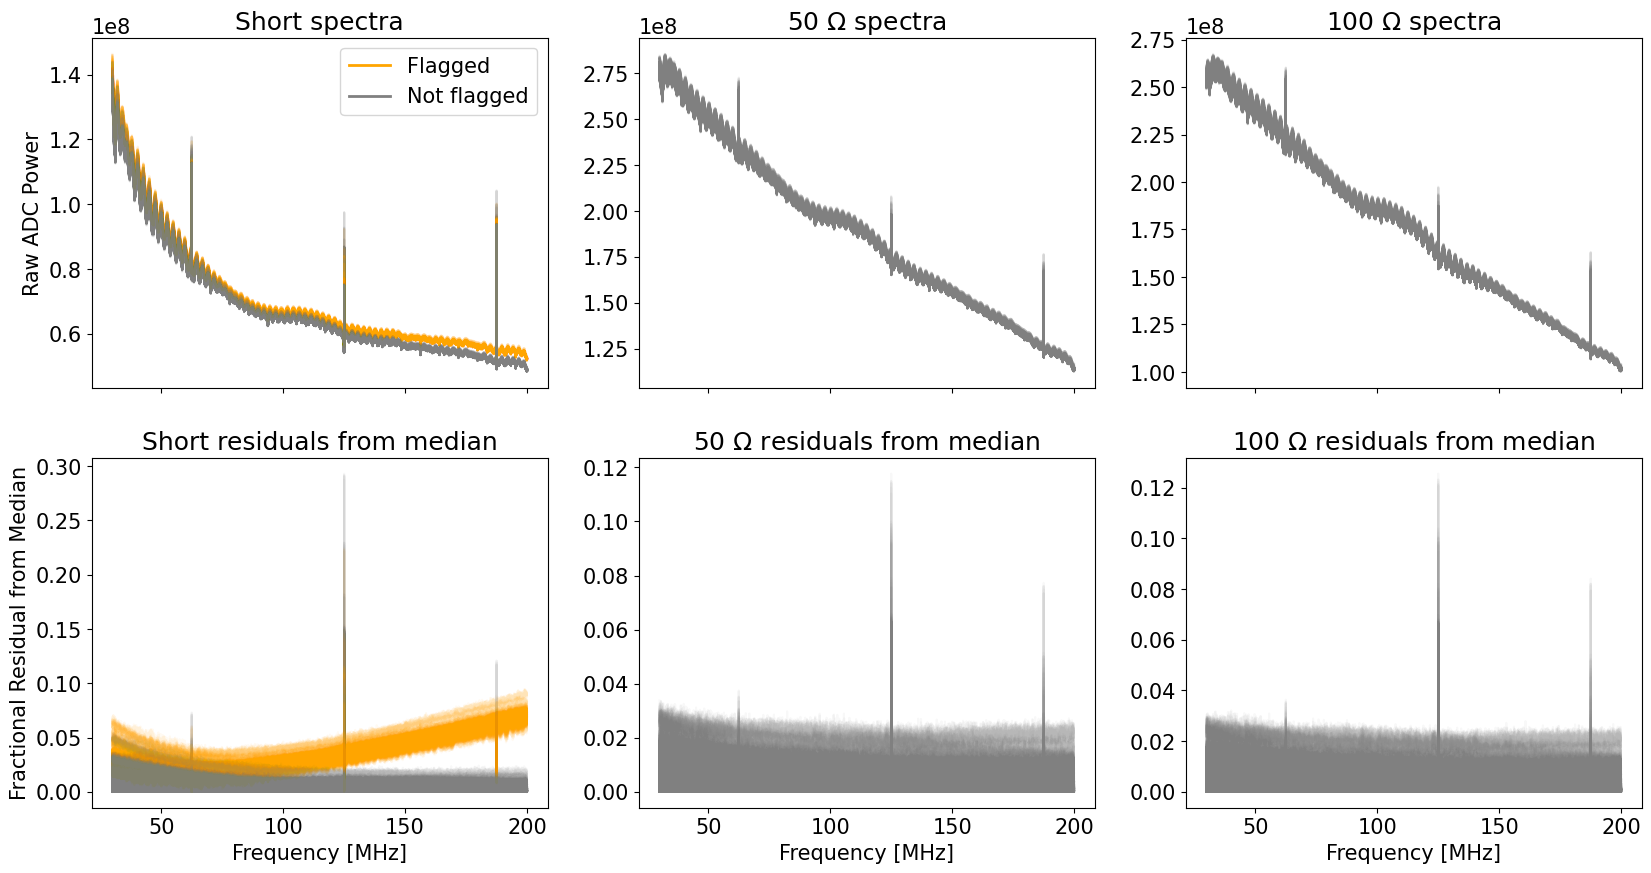

There are 719 bad short spectra, that is 17.91677049588836 % of the short spectra.


In [44]:
'''Scatter plots of raw spectra and residuals from the median over time'''
num_rows = 2
num_cals = 3 # number of calibrators

plt.rcParams.update({'font.size': 15})
plt.rc('xtick', labelsize=15) 
plt.rc('ytick', labelsize=15) 
fig, axs = plt.subplots(num_rows, num_cals, figsize=(20,10), sharex='col')
# gs = fig.add_gridspec(num_rows, num_cals)
# axs = gs.subplots(sharex='col', sharey=False)
axs = axs.flatten() # Flatten the axs array for easier iteration

# Count how many weird short spectra there are
countsh = 0
# Count how many total short spectra there are
nspectra = 0

# Testing:
# for n_day in range(len(data_splitshort)):
#     nspectra += data_splitshort[n_day].shape[0]

# Loop through the subplots
for j in range(num_rows*num_cals):
    # Loop through days, number of days **should** be the same for all calibrators
    for n_day in range(len(data_splitshort)):
        
        # Loop through spectra, number of spectra is *not necessarily* the same for all calibrators
        
        # short spectra
        if j == 0:
            for i in range(data_splitshort[n_day].shape[0]):
                if res_splitshort[n_day][i,maxfreqarg] >= 0.03:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                else:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylabel('Raw ADC Power')
            axs[j].set_title('Short spectra')
            # axs[j].legend(loc='upper right')
        
        # res50 spectra
        if j == 1:
            for i in range(data_splitres50[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'50 $\Omega$ spectra')
            
        # res100 spectra
        if j == 2:
            for i in range(data_splitres100[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'100 $\Omega$ spectra')
            
        # short residuals from median    
        if j == 3:
            nspectra += data_splitshort[n_day].shape[0]
            # print('Short odd spectra:')
            for i in range(res_splitshort[n_day].shape[0]): 
                if res_splitshort[n_day][i,maxfreqarg] >= 0.03:
                    # print('day',n_day,'LST',lst_splitshort[n_day][i],'LSTi',i) # printing out which spectra constitute the weird one(s)
                    countsh += 1
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                else:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylabel('Fractional Residual from Median')
            axs[j].set_title('Short residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
                    
        # res50 residuals from median
        if j == 4:
            # print('Res50 odd spectra:')
            for i in range(res_splitres50[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        # print('day',n_day,'LST',lst_splitres50[n_day][i],'LSTi',i)
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'50 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
             
        # res100 residuals from median
        if j == 5:
            # print('Res100 odd spectra:')
            for i in range(res_splitres100[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        # print('day',n_day,'LST',lst_splitres100[n_day][i],'LSTi',i)
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'100 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
            
# plt.suptitle(instrument+','+channel+','+year,fontsize=20,y=0.95)


from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='orange', lw=2, label='Flagged'),
    Line2D([0], [0], color='grey', lw=2, label='Not flagged')
]
axs[0].legend(handles=legend_elements, loc='upper right')

# plt.savefig(year+'_'+instrument+'_'+channel+'_all-calib-spectra-post-flagging.jpg',dpi=300,bbox_inches='tight')
plt.show()

print('There are',countsh,'bad short spectra, that is',countsh/nspectra*100,'% of the short spectra.') # need to implement a percentage too

In [17]:
'''Save data for future use'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
du.save_all_data(filepath,dataprep,instrument,channel,year,SaveAnt=True)

In [12]:
# Day 15 data investigation
n_day = 15
data_shortd15 = data_splitshort[n_day]
res_shortd15 = res_splitshort[n_day]
data_res50d15 = data_splitres50[n_day]
res_res50d15 = res_splitres50[n_day]
data_res100d15 = data_splitres100[n_day]
res_res100d15 = res_splitres100[n_day]

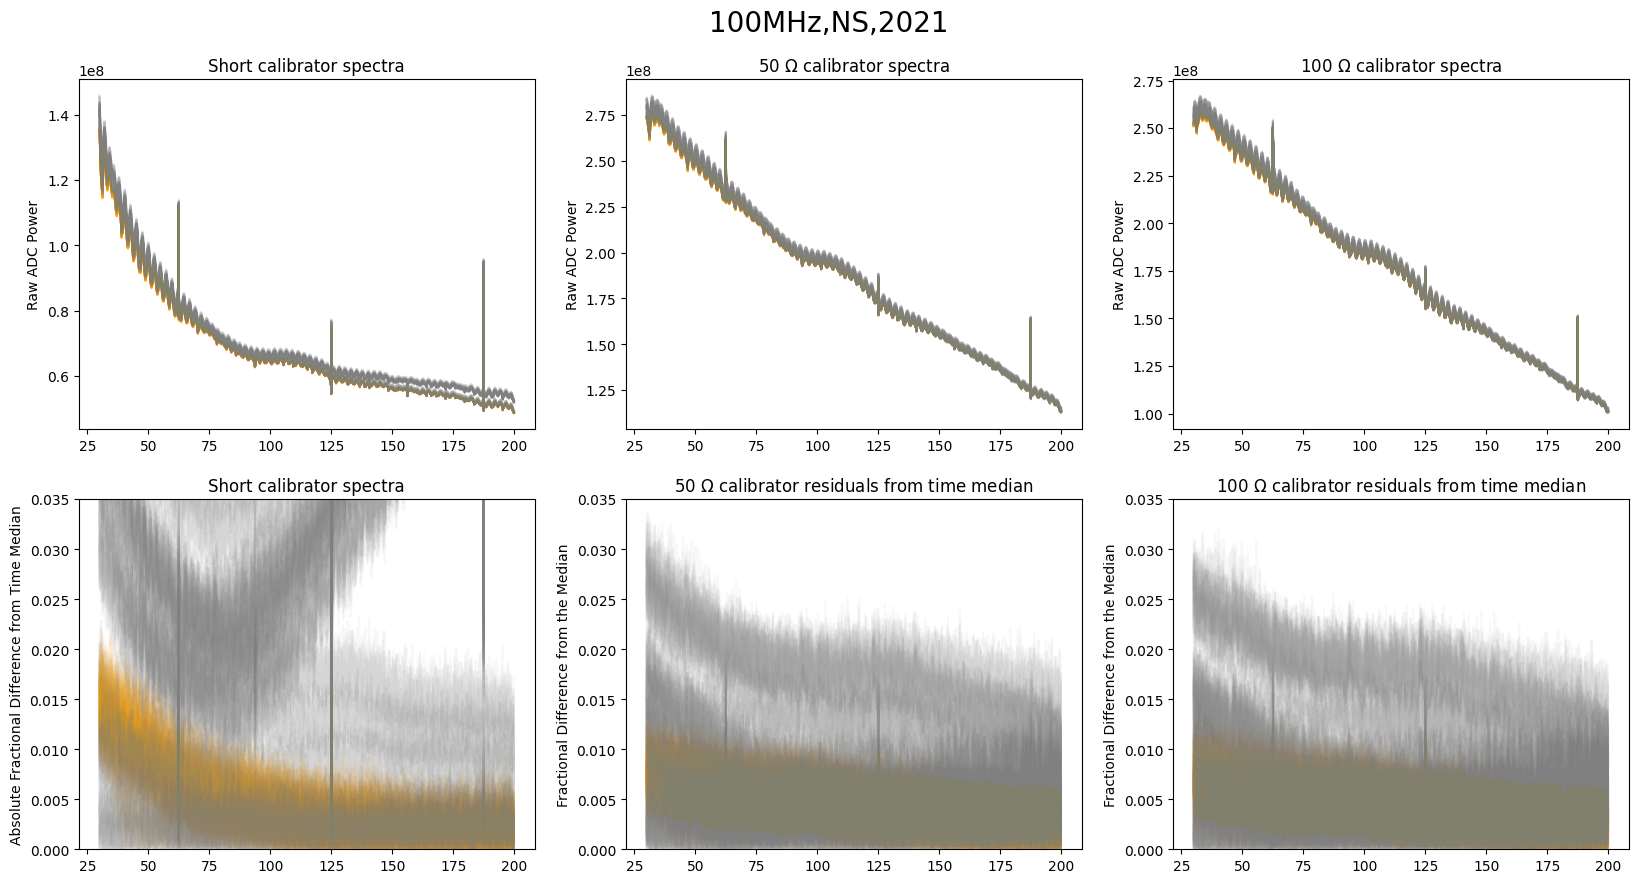

In [13]:
# ONLY DAY 15 DATA
num_rows = 2
num_cals = 3 # number of calibrators

fig, axs = plt.subplots(num_rows, num_cals, figsize=(20,10))
axs = axs.flatten() # Flatten the axs array for easier iteration

for j in range(num_rows*num_cals):
    # short spectra
    if j == 0:
        for i in range(data_shortd15.shape[0]):
            if lst_splitshort[n_day][i] >= 3 and lst_splitshort[n_day][i] <= 11:
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_shortd15[i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
            else:
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_shortd15[i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                
        axs[j].set_ylabel('Raw ADC Power')
        axs[j].set_title('Short calibrator spectra')
        
    # res50 spectra
    elif j == 1:
        for i in range(data_res50d15.shape[0]):
            if lst_splitres50[n_day][i] >= 3 and lst_splitres50[n_day][i] <= 11:
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_res50d15[i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
            else:
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_res50d15[i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
        axs[j].set_ylabel('Raw ADC Power')
        axs[j].set_title(r'50 $\Omega$ calibrator spectra')
        
    
    # res100 spectra
    elif j == 2:
        for i in range(data_res100d15.shape[0]):
            if lst_splitres100[n_day][i] >= 3 and lst_splitres100[n_day][i] <= 11:
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_res100d15[i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
            else:
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_res100d15[i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
        axs[j].set_ylabel('Raw ADC Power')
        axs[j].set_title(r'100 $\Omega$ calibrator spectra')
    
    # short residual
    elif j == 3:
        for i in range(data_shortd15.shape[0]):
            if lst_splitshort[n_day][i] >= 3 and lst_splitshort[n_day][i] <= 11:
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_shortd15[i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
            else:
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_shortd15[i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)   
        axs[j].set_ylim(bottom=0,top=0.035)
        axs[j].set_ylabel('Absolute Fractional Difference from Time Median')
        axs[j].set_title('Short calibrator spectra')
    
    # res50 residual
    elif j == 4:
        for i in range(res_res50d15.shape[0]):
            if lst_splitres50[n_day][i] >= 3 and lst_splitres50[n_day][i] <= 11:
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_res50d15[i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
            else:
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_res50d15[i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
        axs[j].set_ylim(bottom=0,top=0.035)
        axs[j].set_ylabel('Fractional Difference from the Median')
        axs[j].set_title(r'50 $\Omega$ calibrator residuals from time median')
        
   # res100 residuals from median
    elif j == 5:
        for i in range(res_res100d15.shape[0]):
            if lst_splitres100[n_day][i] >= 3 and lst_splitres100[n_day][i] <= 11:
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_res100d15[i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
            else:
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_res100d15[i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
        axs[j].set_ylim(bottom=0,top=0.035)
        axs[j].set_ylabel('Fractional Difference from the Median')
        axs[j].set_title(r'100 $\Omega$ calibrator residuals from time median') 

plt.suptitle(instrument+','+channel+','+year,fontsize=20,y=0.95)
plt.show()
            

### 2018, 100MHz, NS

In [9]:
# 2021, 100 MHZ, NS
year = '2018'
instrument = '100MHz'
channel = 'NS'

In [10]:
# dataprep = DataPrep(instrument, channel, year)
'''Data has been saved, load in with load_all_data()'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
dataprep = du.load_all_data(filepath,instrument,channel,year,LoadAnt=False,LoadInterpCalib=False)
print(dataprep.keys())

dict_keys(['antlst', 'antsystime', 'shortdata_meas', 'shortlst', 'shortsystime', 'res50data_meas', 'res50lst', 'res50systime', 'res100data_meas', 'res100lst', 'res100systime'])


In [20]:
# Interpolated spectra waterfall plots

datashort = dataprep.shorts
lstshort = dataprep.lst
print(len(lstshort[lstshort == np.nan]))

# waterfall_alldays(datashort,lstshort,freqarr,source='Short') # raw spectra

du.time_variation(datashort,lstshort,freqarr,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

# for some reason this gives an error about NaNs

AttributeError: 'dict' object has no attribute 'shorts'

In [11]:
# Measured spectra waterfall plots

# Short
try:
    datashort_meas = dataprep.shorts_data
    lstshort_meas = dataprep.shorts_data_lst
except:
    print('Using saved data')
    datashort_meas = dataprep['shortdata_meas']
    lstshort_meas = dataprep['shortlst']

# du.time_variation(datashort_meas,lstshort_meas,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

# res50
try:
    datares50_meas = dataprep.res50_data
    lstres50_meas = dataprep.res50_data_lst
except:
    print('Using saved data')
    datares50_meas = dataprep['res50data_meas']
    lstres50_meas = dataprep['res50lst']

# du.time_variation(datares50_meas,lstres50_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'50 $\Omega$',plot_type='waterfall') # variation from the mean = median absolute deviation

# res100
try:
    datares100_meas = dataprep.res100_data
    lstres100_meas = dataprep.res100_data_lst
except:
    print('Using saved data')
    datares100_meas = dataprep['res100data_meas']
    lstres100_meas = dataprep['res100lst']

# du.time_variation(datares100_meas,lstres100_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'100 $\Omega$',plot_type='waterfall') # variation from the mean = median absolute deviation

Using saved data
Using saved data
Using saved data


In [12]:
# 2D plots wrt frequency
n_day = 17 # random day to check array dimensions

'''Short'''
# Prep the data
print(datashort_meas.shape)
print(lstshort_meas.shape)

# Compute median over all days, and residuals from median
time_medianshort = np.median(datashort_meas,axis=0)
res_datashort = np.abs((datashort_meas - time_medianshort)/time_medianshort)
systimeshort_meas_2018_100_NS = dataprep['shortsystime'] # save some data to compare with another dataset
res_datashort_2018_100_NS = res_datashort

# Split into different days
lst_splitshort, data_splitshort = du.LST_days_split(lstshort_meas,datashort_meas)
lst_splitshort, res_splitshort = du.LST_days_split(lstshort_meas,res_datashort)

print(data_splitshort[n_day].shape)
print(lst_splitshort[n_day].shape)
# dimensions also check out


'''res50'''
# Prep the data
print(datares50_meas.shape)
print(lstres50_meas.shape)

# Compute median over all days, and residuals from median
time_medianres50 = np.median(datares50_meas,axis=0)
res_datares50 = np.abs((datares50_meas - time_medianres50)/time_medianres50)

# Split into different days
lst_splitres50, data_splitres50 = du.LST_days_split(lstres50_meas,datares50_meas)
lst_splitres50, res_splitres50 = du.LST_days_split(lstres50_meas,res_datares50)

print(data_splitres50[n_day].shape)
print(lst_splitres50[n_day].shape)
# dimensions also check out


'''res100'''
# Prep the data
print(datares100_meas.shape)
print(lstres100_meas.shape)

# Compute median over all days, and residuals from median
time_medianres100 = np.median(datares100_meas,axis=0)
res_datares100 = np.abs((datares100_meas - time_medianres100)/time_medianres100)

# Split into different days
lst_splitres100, data_splitres100 = du.LST_days_split(lstres100_meas,datares100_meas)
lst_splitres100, res_splitres100 = du.LST_days_split(lstres100_meas,res_datares100)

print(data_splitres100[n_day].shape)
print(lst_splitres100[n_day].shape)
# dimensions also check out

(3791, 4096)
(3791,)
(146, 4096)
(146,)
(3864, 4096)
(3864,)
(152, 4096)
(152,)
(3814, 4096)
(3814,)
(147, 4096)
(147,)


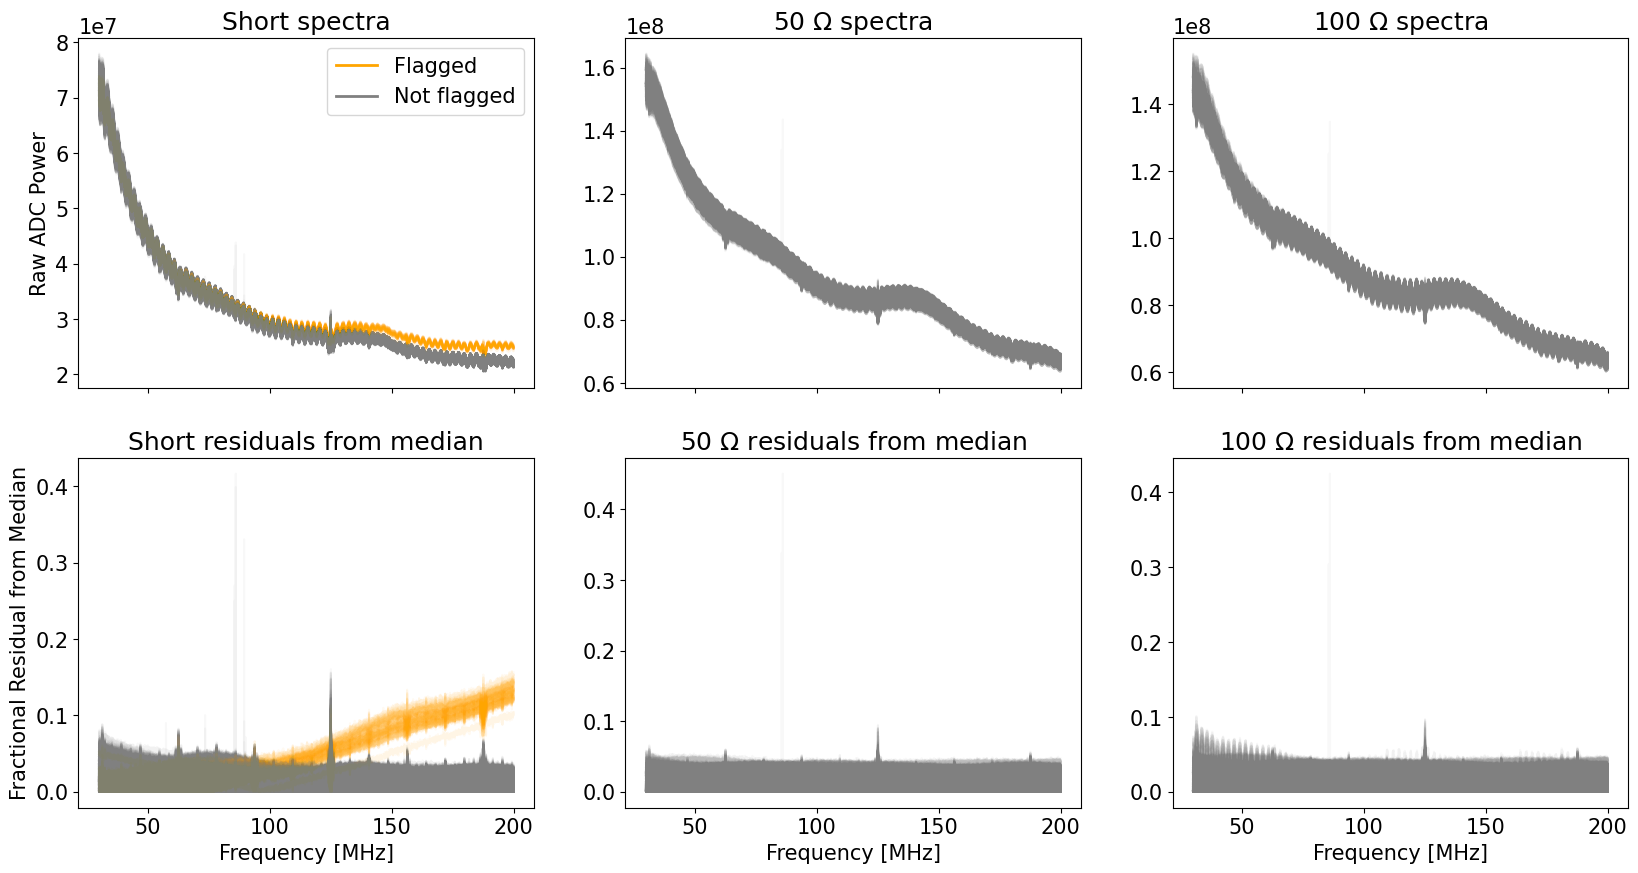

There are 75 bad short spectra, that is 1.9783698232656293 % of the short spectra.


In [13]:
'''Scatter plots of raw spectra and residuals from the median over time'''
num_rows = 2
num_cals = 3 # number of calibrators

plt.rcParams.update({'font.size': 15})
plt.rc('xtick', labelsize=15) 
plt.rc('ytick', labelsize=15) 
fig, axs = plt.subplots(num_rows, num_cals, figsize=(20,10), sharex='col')
# gs = fig.add_gridspec(num_rows, num_cals)
# axs = gs.subplots(sharex='col', sharey=False)
axs = axs.flatten() # Flatten the axs array for easier iteration

# Count how many weird short spectra there are
countsh = 0
# Count how many total short spectra there are
nspectra = 0

# Testing:
# for n_day in range(len(data_splitshort)):
#     nspectra += data_splitshort[n_day].shape[0]

# Loop through the subplots
for j in range(num_rows*num_cals):
    # Loop through days, number of days **should** be the same for all calibrators
    for n_day in range(len(data_splitshort)):
        
        # Loop through spectra, number of spectra is *not necessarily* the same for all calibrators
        
        # short spectra
        if j == 0:
            for i in range(data_splitshort[n_day].shape[0]):
                if res_splitshort[n_day][i,maxfreqarg] >= 0.09:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                else:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylabel('Raw ADC Power')
            axs[j].set_title('Short spectra')
            # axs[j].legend(loc='upper right')
        
        # res50 spectra
        if j == 1:
            for i in range(data_splitres50[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'50 $\Omega$ spectra')
            
        # res100 spectra
        if j == 2:
            for i in range(data_splitres100[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'100 $\Omega$ spectra')
            
        # short residuals from median    
        if j == 3:
            nspectra += data_splitshort[n_day].shape[0]
            # print('Short odd spectra:')
            for i in range(res_splitshort[n_day].shape[0]): 
                if res_splitshort[n_day][i,maxfreqarg] >= 0.09:
                    # print('day',n_day,'LST',lst_splitshort[n_day][i],'LSTi',i) # printing out which spectra constitute the weird one(s)
                    countsh += 1
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                else:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylabel('Fractional Residual from Median')
            axs[j].set_title('Short residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
                    
        # res50 residuals from median
        if j == 4:
            # print('Res50 odd spectra:')
            for i in range(res_splitres50[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        # print('day',n_day,'LST',lst_splitres50[n_day][i],'LSTi',i)
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'50 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
             
        # res100 residuals from median
        if j == 5:
            # print('Res100 odd spectra:')
            for i in range(res_splitres100[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        # print('day',n_day,'LST',lst_splitres100[n_day][i],'LSTi',i)
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'100 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
            
# plt.suptitle(instrument+','+channel+','+year,fontsize=20,y=0.95)


from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='orange', lw=2, label='Flagged'),
    Line2D([0], [0], color='grey', lw=2, label='Not flagged')
]
axs[0].legend(handles=legend_elements, loc='upper right')

plt.savefig(year+'_'+instrument+'_'+channel+'_all-calib-spectra-post-flagging.jpg',dpi=300,bbox_inches='tight')
plt.show()

print('There are',countsh,'bad short spectra, that is',countsh/nspectra*100,'% of the short spectra.') # need to implement a percentage too

In [81]:
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
du.save_all_data(filepath,dataprep,instrument,channel,year,SaveAnt=True,SaveInterpCalib=False)

### 2021, 70 MHz, EW

In [3]:
# 2021, 70 MHZ, EW
year = '2021'
instrument = '70MHz'
channel = 'EW'

In [4]:
# dataprep = DataPrep(instrument, channel, year)
'''Data has been saved, load in with load_all_data()'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
dataprep = du.load_all_data(filepath,instrument,channel,year,LoadAnt=False,LoadInterpCalib=False)
print(dataprep.keys())

dict_keys(['antdata', 'antlst', 'antsystime', 'shortdata_meas', 'shortlst', 'shortsystime', 'res50data_meas', 'res50lst', 'res50systime', 'res100data_meas', 'res100lst', 'res100systime'])


In [5]:
dataprep['antdata'].shape

(324449, 4096)

In [ ]:
short_mask = self.calib_mask_dict['short']
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
np.save(filepath+'shortdata_2021_70MHz_EW_mask.npy',short_mask)
# short_mask = np.load(filepath+'shortdata_2021_70MHz_EW_mask.npy')

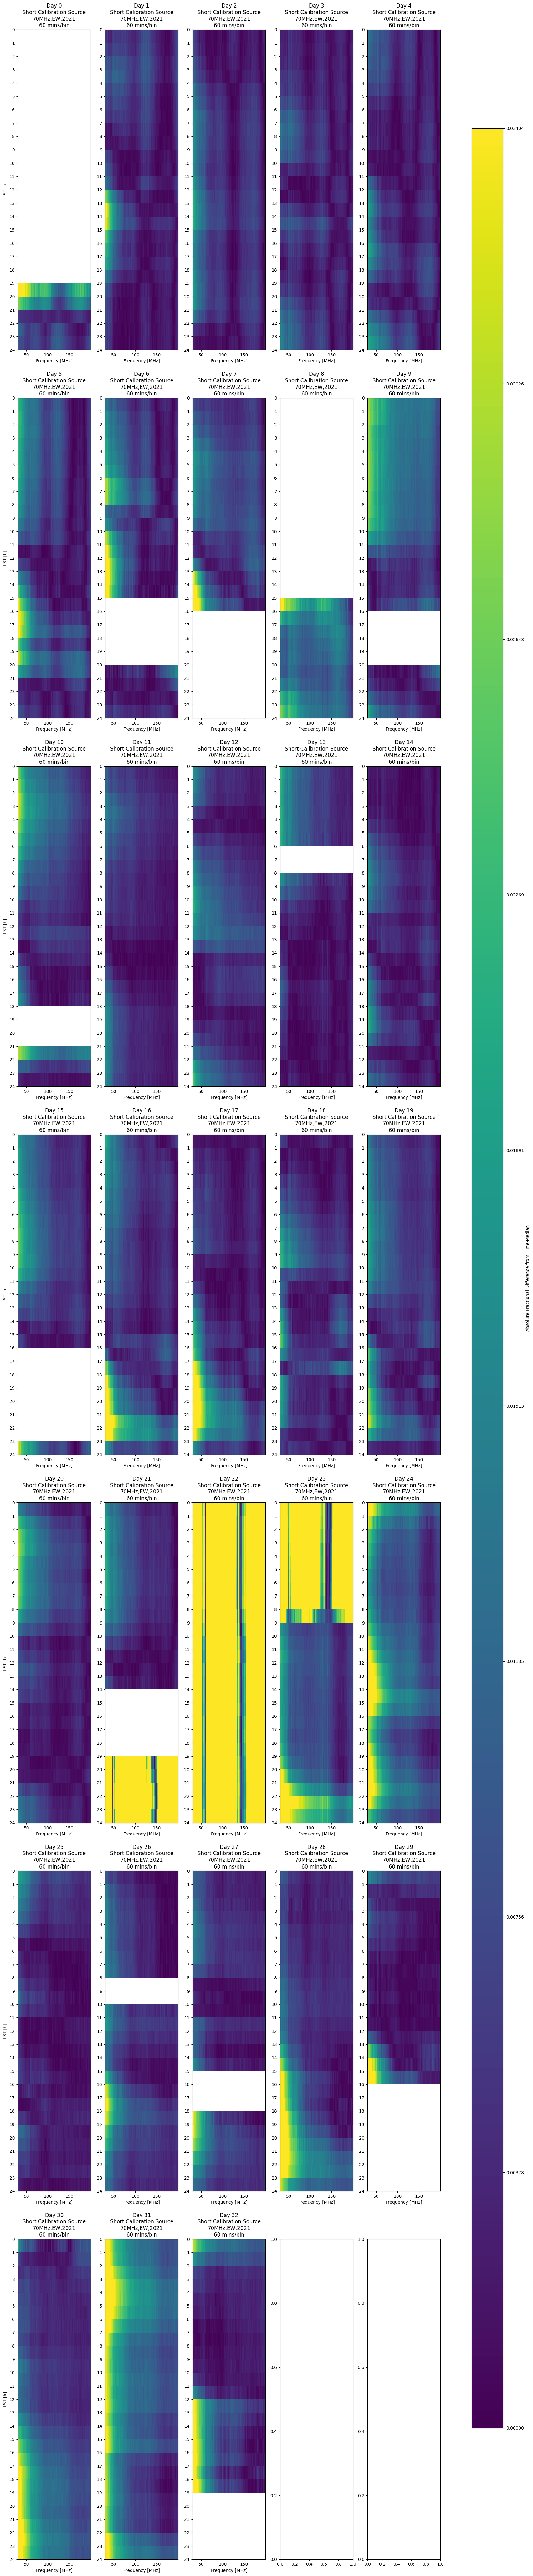

In [48]:
# Interpolated spectra waterfall plots

datashort = dataprep.shorts
lstshort = dataprep.lst
# print(len(lstshort[lstshort == np.nan]))

# waterfall_alldays(datashort,lstshort,freqarr,source='Short') # raw spectra

du.time_variation(datashort,lstshort,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

In [42]:
# Measured spectra waterfall plots

# Short
try:
    datashort_meas = dataprep.shorts_data
    lstshort_meas = dataprep.shorts_data_lst
except:
    print('Using saved data')
    datashort_meas = dataprep['shortdata_meas']
    lstshort_meas = dataprep['shortlst']

# du.time_variation(datashort_meas,lstshort_meas,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

# res50
try:
    datares50_meas = dataprep.res50_data
    lstres50_meas = dataprep.res50_data_lst
except:
    print('Using saved data')
    datares50_meas = dataprep['res50data_meas']
    lstres50_meas = dataprep['res50lst']

# du.time_variation(datares50_meas,lstres50_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'50 $\Omega$',plot_type='waterfall') # variation from the mean = median absolute deviation

# res100
try:
    datares100_meas = dataprep.res100_data
    lstres100_meas = dataprep.res100_data_lst
except:
    print('Using saved data')
    datares100_meas = dataprep['res100data_meas']
    lstres100_meas = dataprep['res100lst']

# du.time_variation(datares100_meas,lstres100_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'100 $\Omega$',plot_type='waterfall') # variation from the mean = median absolute deviation

Using saved data
Using saved data
Using saved data


In [43]:
# 2D plots wrt frequency
n_day = 17 # random day to check array dimensions

'''Short'''
# Prep the data
print(datashort_meas.shape)
print(lstshort_meas.shape)

# Compute median over all days, and residuals from median
time_medianshort = np.median(datashort_meas,axis=0)
res_datashort = np.abs((datashort_meas - time_medianshort)/time_medianshort)
systimeshort_meas_2021_70_EW = dataprep['shortsystime'] # save some data to compare with another dataset
res_datashort_2021_70_EW = res_datashort

# Split into different days
lst_splitshort, data_splitshort = du.LST_days_split(lstshort_meas,datashort_meas)
lst_splitshort, res_splitshort = du.LST_days_split(lstshort_meas,res_datashort)

print(data_splitshort[n_day].shape)
print(lst_splitshort[n_day].shape)
# dimensions also check out


'''res50'''
# Prep the data
print(datares50_meas.shape)
print(lstres50_meas.shape)

# Compute median over all days, and residuals from median
time_medianres50 = np.median(datares50_meas,axis=0)
res_datares50 = np.abs((datares50_meas - time_medianres50)/time_medianres50)

# Split into different days
lst_splitres50, data_splitres50 = du.LST_days_split(lstres50_meas,datares50_meas)
lst_splitres50, res_splitres50 = du.LST_days_split(lstres50_meas,res_datares50)

print(data_splitres50[n_day].shape)
print(lst_splitres50[n_day].shape)
# dimensions also check out


'''res100'''
# Prep the data
print(datares100_meas.shape)
print(lstres100_meas.shape)

# Compute median over all days, and residuals from median
time_medianres100 = np.median(datares100_meas,axis=0)
res_datares100 = np.abs((datares100_meas - time_medianres100)/time_medianres100)

# Split into different days
lst_splitres100, data_splitres100 = du.LST_days_split(lstres100_meas,datares100_meas)
lst_splitres100, res_splitres100 = du.LST_days_split(lstres100_meas,res_datares100)

print(data_splitres100[n_day].shape)
print(lst_splitres100[n_day].shape)
# dimensions also check out

(7869, 4096)
(7869,)
(276, 4096)
(276,)
(8056, 4096)
(8056,)
(275, 4096)
(275,)
(7990, 4096)
(7990,)
(277, 4096)
(277,)


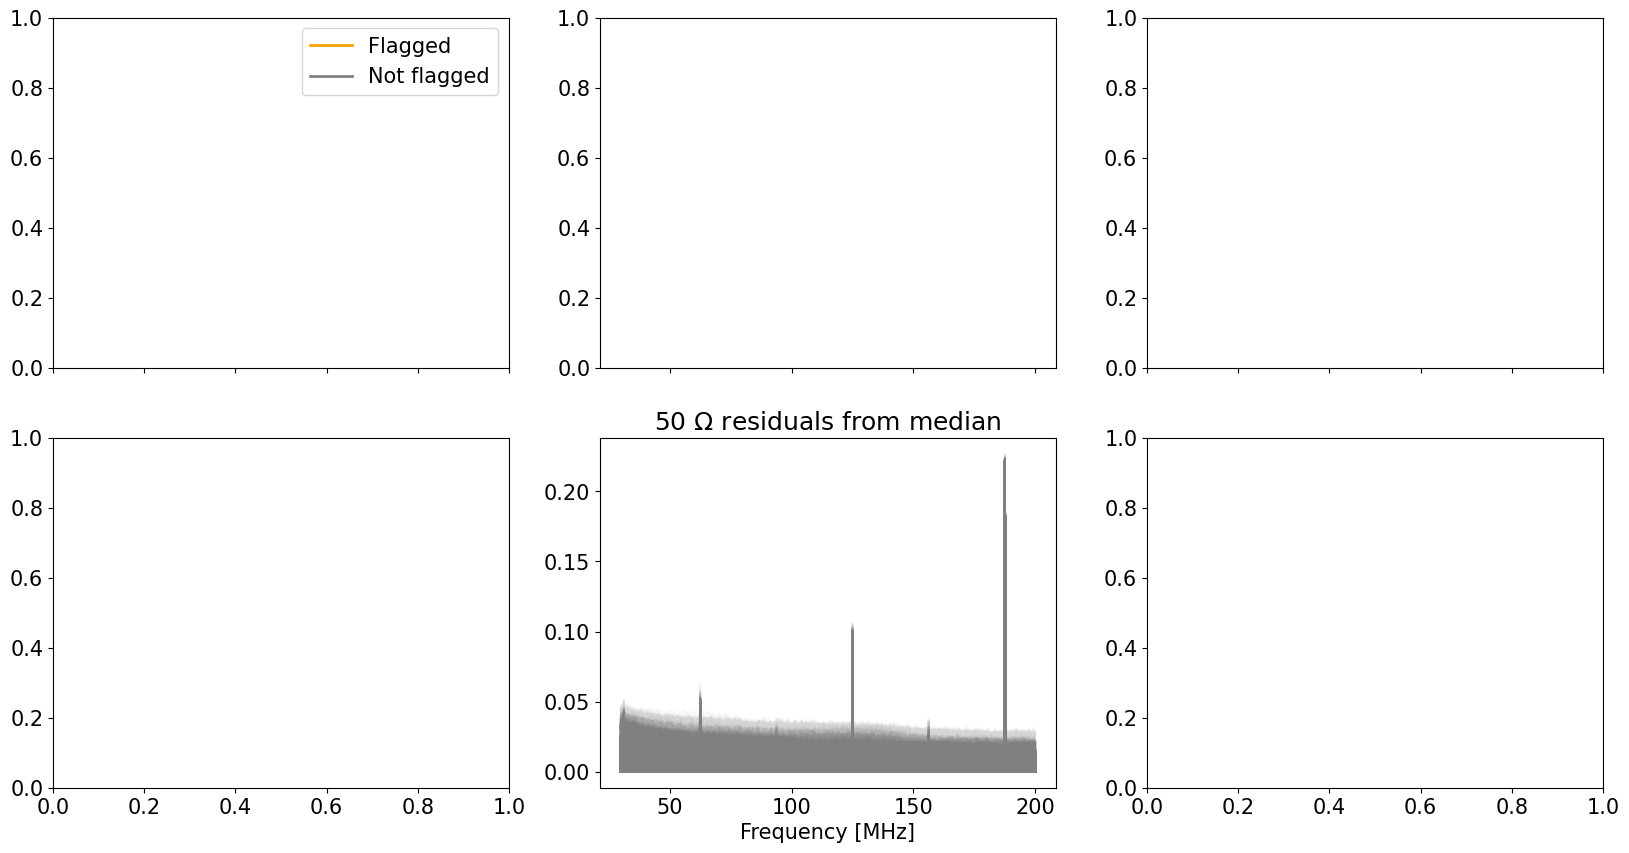

ZeroDivisionError: division by zero

In [7]:
'''Scatter plots of raw spectra and residuals from the median over time'''
num_rows = 2
num_cals = 3 # number of calibrators

plt.rcParams.update({'font.size': 15})
plt.rc('xtick', labelsize=15) 
plt.rc('ytick', labelsize=15) 
fig, axs = plt.subplots(num_rows, num_cals, figsize=(20,10), sharex='col')
# gs = fig.add_gridspec(num_rows, num_cals)
# axs = gs.subplots(sharex='col', sharey=False)
axs = axs.flatten() # Flatten the axs array for easier iteration

# Count how many weird short spectra there are
countsh = 0
# Count how many total short spectra there are
nspectra = 0

# Testing:
# for n_day in range(len(data_splitshort)):
#     nspectra += data_splitshort[n_day].shape[0]

# Loop through the subplots
for j in range(num_rows*num_cals):
    # Loop through days, number of days **should** be the same for all calibrators
    for n_day in range(len(data_splitshort)):
        
        # Loop through spectra, number of spectra is *not necessarily* the same for all calibrators
        
        # short spectra
        if j == 0:
            for i in range(data_splitshort[n_day].shape[0]):
                if res_splitshort[n_day][i,minfreqarg] >= 0.15:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                else:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylabel('Raw ADC Power')
            axs[j].set_title('Short spectra')
            # axs[j].legend(loc='upper right')
        
        # res50 spectra
        if j == 1:
            for i in range(data_splitres50[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'50 $\Omega$ spectra')
            
        # res100 spectra
        if j == 2:
            for i in range(data_splitres100[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'100 $\Omega$ spectra')
            
        # short residuals from median    
        if j == 3:
            nspectra += data_splitshort[n_day].shape[0]
            # print('Short odd spectra:')
            for i in range(res_splitshort[n_day].shape[0]): 
                if res_splitshort[n_day][i,minfreqarg] >= 0.15:
                    # print('day',n_day,'LST',lst_splitshort[n_day][i],'LSTi',i) # printing out which spectra constitute the weird one(s)
                    countsh += 1
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                else:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylabel('Fractional Residual from Median')
            axs[j].set_title('Short residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
                    
        # res50 residuals from median
        if j == 4:
            # print('Res50 odd spectra:')
            for i in range(res_splitres50[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        # print('day',n_day,'LST',lst_splitres50[n_day][i],'LSTi',i)
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'50 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
             
        # res100 residuals from median
        if j == 5:
            # print('Res100 odd spectra:')
            for i in range(res_splitres100[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        # print('day',n_day,'LST',lst_splitres100[n_day][i],'LSTi',i)
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'100 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
            
# plt.suptitle(instrument+','+channel+','+year,fontsize=20,y=0.95)


from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='orange', lw=2, label='Flagged'),
    Line2D([0], [0], color='grey', lw=2, label='Not flagged')
]
axs[0].legend(handles=legend_elements, loc='upper right')

plt.savefig(year+'_'+instrument+'_'+channel+'_all-calib-spectra-post-flagging.jpg',dpi=300,bbox_inches='tight')
plt.show()

print('There are',countsh,'bad short spectra, that is',countsh/nspectra*100,'% of the short spectra.') # need to implement a percentage too

In [99]:
# Checking flagging stats
print(np.sum(res_datashort[:,maxfreqarg] >= 0.15) / res_datashort.shape[0])

0.050196975473376544


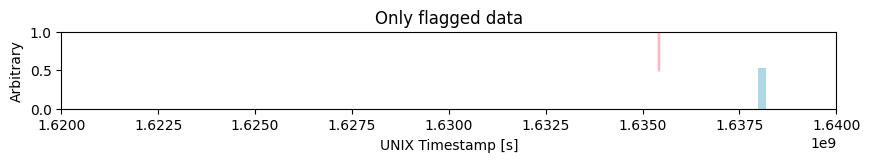

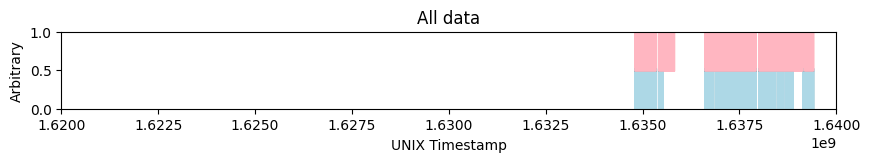

In [60]:
# Comparing times of flagged short spectra for 2021 70EW and 2021 100EW
systf_2021_70_EW = systimeshort_meas_2021_70_EW[res_datashort_2021_70_EW[:,minfreqarg] >= 0.15]

systf_2021_100_EW = systimeshort_meas_2021_100_EW[res_datashort_2021_100_EW[:,maxfreqarg] >= 0.15]

import matplotlib.dates as mdates
from datetime import datetime, timezone
# Plot the times
plt.figure(figsize=(10,1))
plt.rcParams.update({'font.size': 10})
for i in range(len(systf_2021_70_EW)):
    # plt.axvline((systf_2021_70_EW[i]-systf_2021_70_EW[0])/3600,color='lightblue',ymin=0,ymax=0.5) # in hours
    plt.axvline(systf_2021_70_EW[i],color='lightblue',ymin=0,ymax=0.5) # in UNIX timestamp
    # plt.axvline(datetime.fromtimestamp(systf_2021_70_EW[i], tz=timezone.utc),color='lightblue',ymin=0,ymax=0.5) # in UTC
    
for i in range(len(systf_2021_100_EW)):
    # plt.axvline((systf_2021_100_EW[i]-systf_2021_70_EW[0])/3600,color='lightpink',ymin=0.5,ymax=1) # in hours
    plt.axvline(systf_2021_100_EW[i],color='lightpink',ymin=0.5,ymax=1) # in UNIX
    # plt.axvline(datetime.fromtimestamp(systf_2021_100_EW[i], tz=timezone.utc),color='lightpink',ymin=0.5,ymax=1) # in UTC

# Set x-axis format to date only (e.g., "2025-06-21")
# date_format = mdates.DateFormatter('%Y-%m-%d')  # Or '%b %d' for "Jun 21"
# ax = plt.gca()
# ax.xaxis.set_major_formatter(date_format)
# # Rotate date labels (optional)
# plt.gcf().autofmt_xdate()

plt.xlabel('UNIX Timestamp [s]')
plt.ylabel('Arbitrary')
# x_start = datetime(2021, 7, 1, tzinfo=timezone.utc)
# x_end = datetime(2021, 12, 31, tzinfo=timezone.utc)
# plt.xlim(x_start, x_end)
plt.xlim(left=1.62e9,right=1.64e9)
plt.title('Only flagged data')
plt.show()

plt.figure(figsize=(10,1))
plt.rcParams.update({'font.size': 10})
for i in range(len(systimeshort_meas_2021_70_EW)):
    # plt.axvline((systimeshort_meas_2021_70_EW[i]-systimeshort_meas_2021_70_EW[0])/3600,color='lightblue',ymin=0,ymax=0.5) # in hours
    plt.axvline(systimeshort_meas_2021_70_EW[i],color='lightblue',ymin=0,ymax=0.5) # in UNIX
    # plt.axvline(systimeshort_meas_2021_70_EW[i]),color='lightblue',ymin=0,ymax=0.5) # in UTC
for i in range(len(systimeshort_meas_2021_100_EW)):
    # plt.axvline((systimeshort_meas_2021_100_EW[i]-systimeshort_meas_2021_70_EW[0])/3600,color='lightblue',ymin=0,ymax=0.5) # in hours
    plt.axvline(systimeshort_meas_2021_100_EW[i],color='lightpink',ymin=0.5,ymax=1) # in UNIX
plt.xlabel('UNIX Timestamp')
plt.ylabel('Arbitrary')
plt.xlim(left=1.62e9,right=1.64e9)
plt.title('All data')
plt.show()

In [49]:
# Easy way to convert from UNIX timestamp to a UTC date and time :)
from datetime import datetime
ts = int(1634831208)
print(datetime.fromtimestamp(ts).strftime('%Y-%m-%d %H:%M:%S'))

1634831208.4040756


In [60]:
'''Save data for future use'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
du.save_all_data(filepath,dataprep,instrument,channel,year,SaveAnt=True,SaveInterpCalib=False)

### 2021, 100 MHz, EW

In [2]:
year = '2021'
instrument = '100MHz'
channel = 'EW'

In [4]:
# dataprep = DataPrep(instrument, channel, year)
'''Data has been saved, load in with load_all_data()'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
dataprep = du.load_all_data(filepath,instrument,channel,year,LoadAnt=False,LoadInterpCalib=False)
print(dataprep.keys())

dict_keys(['antdata', 'antlst', 'antsystime', 'shortdata_meas', 'shortlst', 'shortsystime', 'res50data_meas', 'res50lst', 'res50systime', 'res100data_meas', 'res100lst', 'res100systime'])


In [5]:
dataprep['antdata'].shape

(425374, 4096)

In [ ]:
# Interpolated spectra waterfall plots

try:
    datashort = dataprep.shorts
    lstshort = dataprep.lst
except:
    print('Using saved data')
    datashort = dataprep['shortinterp']
    lstshort = dataprep['antsystime']
    
# print(len(lstshort[lstshort == np.nan]))

# waterfall_alldays(datashort,lstshort,freqarr,source='Short') # raw spectra

du.time_variation(datashort,lstshort,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

In [5]:
# Measured spectra waterfall plots

# Short
try:
    datashort_meas = dataprep.shorts_data
    lstshort_meas = dataprep.shorts_data_lst
except:
    print('Using saved data')
    datashort_meas = dataprep['shortdata_meas']
    lstshort_meas = dataprep['shortlst']

# du.time_variation(datashort_meas,lstshort_meas,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

# res50
try:
    datares50_meas = dataprep.res50_data
    lstres50_meas = dataprep.res50_data_lst
except:
    print('Using saved data')
    datares50_meas = dataprep['res50data_meas']
    lstres50_meas = dataprep['res50lst']

# du.time_variation(datares50_meas,lstres50_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'50 $\Omega$',plot_type='waterfall') # variation from the mean = median absolute deviation

# res100
try:
    datares100_meas = dataprep.res100_data
    lstres100_meas = dataprep.res100_data_lst
except:
    print('Using saved data')
    datares100_meas = dataprep['res100data_meas']
    lstres100_meas = dataprep['res100lst']

# du.time_variation(datares100_meas,lstres100_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'100 $\Omega$',plot_type='waterfall') # variation from the mean = median absolute deviation

Using saved data
Using saved data
Using saved data


In [6]:
# 2D plots wrt frequency
n_day = 17 # random day to check array dimensions

'''Short'''
# Prep the data
print(datashort_meas.shape)
print(lstshort_meas.shape)

# Compute median over all days, and residuals from median
time_medianshort = np.median(datashort_meas,axis=0)
res_datashort = np.abs((datashort_meas - time_medianshort)/time_medianshort)
systimeshort_meas_2021_100_EW = dataprep['shortsystime'] # save some data to compare with another dataset
res_datashort_2021_100_EW = res_datashort

# Split into different days
lst_splitshort, data_splitshort = du.LST_days_split(lstshort_meas,datashort_meas)
lst_splitshort, res_splitshort = du.LST_days_split(lstshort_meas,res_datashort)

print(data_splitshort[n_day].shape)
print(lst_splitshort[n_day].shape)
# dimensions also check out


'''res50'''
# Prep the data
print(datares50_meas.shape)
print(lstres50_meas.shape)

# Compute median over all days, and residuals from median
time_medianres50 = np.median(datares50_meas,axis=0)
res_datares50 = np.abs((datares50_meas - time_medianres50)/time_medianres50)

# Split into different days
lst_splitres50, data_splitres50 = du.LST_days_split(lstres50_meas,datares50_meas)
lst_splitres50, res_splitres50 = du.LST_days_split(lstres50_meas,res_datares50)

print(data_splitres50[n_day].shape)
print(lst_splitres50[n_day].shape)
# dimensions also check out


'''res100'''
# Prep the data
print(datares100_meas.shape)
print(lstres100_meas.shape)

# Compute median over all days, and residuals from median
time_medianres100 = np.median(datares100_meas,axis=0)
res_datares100 = np.abs((datares100_meas - time_medianres100)/time_medianres100)

# Split into different days
lst_splitres100, data_splitres100 = du.LST_days_split(lstres100_meas,datares100_meas)
lst_splitres100, res_splitres100 = du.LST_days_split(lstres100_meas,res_datares100)

print(data_splitres100[n_day].shape)
print(lst_splitres100[n_day].shape)
# dimensions also check out

(10285, 4096)
(10285,)
(219, 4096)
(219,)
(10566, 4096)
(10566,)
(210, 4096)
(210,)
(10464, 4096)
(10464,)
(201, 4096)
(201,)


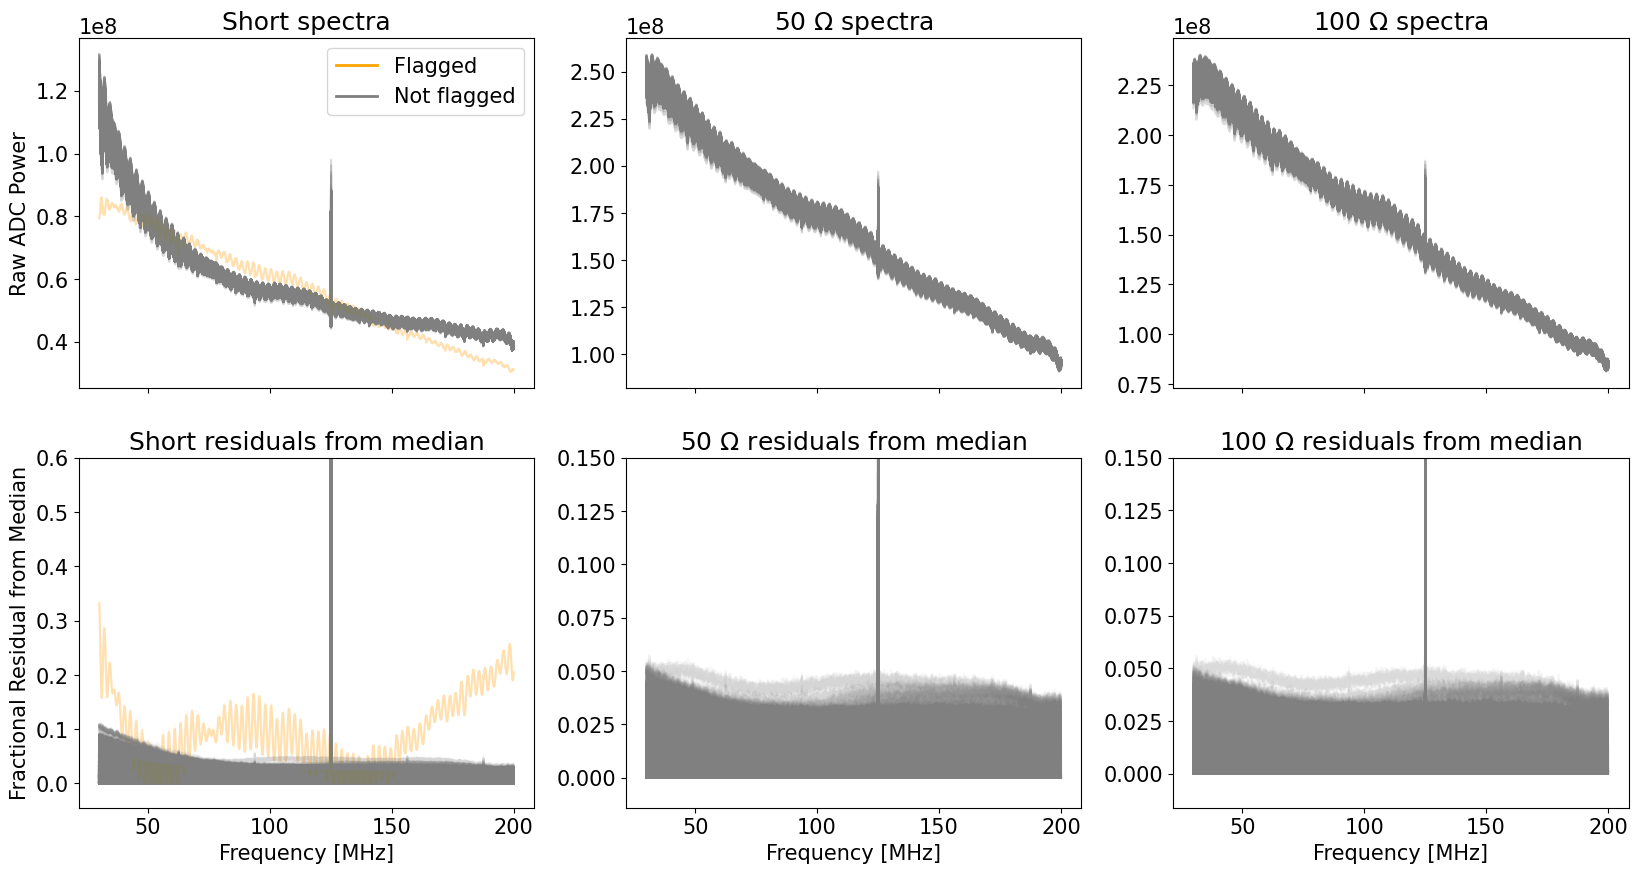

There are 7 bad short spectra, that is 0.06806028196402528 % of the short spectra.


In [8]:
'''Scatter plots of raw spectra and residuals from the median over time'''
num_rows = 2
num_cals = 3 # number of calibrators

plt.rcParams.update({'font.size': 15})
plt.rc('xtick', labelsize=15) 
plt.rc('ytick', labelsize=15) 
fig, axs = plt.subplots(num_rows, num_cals, figsize=(20,10), sharex='col')
# gs = fig.add_gridspec(num_rows, num_cals)
# axs = gs.subplots(sharex='col', sharey=False)
axs = axs.flatten() # Flatten the axs array for easier iteration

# Count how many weird short spectra there are
countsh = 0
# Count how many total short spectra there are
nspectra = 0

# Testing:
# for n_day in range(len(data_splitshort)):
#     nspectra += data_splitshort[n_day].shape[0]

# Loop through the subplots
for j in range(num_rows*num_cals):
    # Loop through days, number of days **should** be the same for all calibrators
    for n_day in range(len(data_splitshort)):
        
        # Loop through spectra, number of spectra is *not necessarily* the same for all calibrators
        
        # short spectra
        if j == 0:
            for i in range(data_splitshort[n_day].shape[0]):
                if res_splitshort[n_day][i,maxfreqarg] >= 0.15:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                else:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylabel('Raw ADC Power')
            axs[j].set_title('Short spectra')
            # axs[j].legend(loc='upper right')
        
        # res50 spectra
        if j == 1:
            for i in range(data_splitres50[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'50 $\Omega$ spectra')
            
        # res100 spectra
        if j == 2:
            for i in range(data_splitres100[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'100 $\Omega$ spectra')
            
        # short residuals from median    
        if j == 3:
            nspectra += data_splitshort[n_day].shape[0]
            # print('Short odd spectra:')
            for i in range(res_splitshort[n_day].shape[0]): 
                if res_splitshort[n_day][i,maxfreqarg] >= 0.15:
                    # print('day',n_day,'LST',lst_splitshort[n_day][i],'LSTi',i) # printing out which spectra constitute the weird one(s)
                    countsh += 1
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                else:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylabel('Fractional Residual from Median')
            axs[j].set_title('Short residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
            axs[j].set_ylim(top=0.6)
                    
        # res50 residuals from median
        if j == 4:
            # print('Res50 odd spectra:')
            for i in range(res_splitres50[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        # print('day',n_day,'LST',lst_splitres50[n_day][i],'LSTi',i)
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'50 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
            axs[j].set_ylim(top=0.15)
             
        # res100 residuals from median
        if j == 5:
            # print('Res100 odd spectra:')
            for i in range(res_splitres100[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        # print('day',n_day,'LST',lst_splitres100[n_day][i],'LSTi',i)
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'100 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
            axs[j].set_ylim(top=0.15)
            
# plt.suptitle(instrument+','+channel+','+year,fontsize=20,y=0.95)


from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='orange', lw=2, label='Flagged'),
    Line2D([0], [0], color='grey', lw=2, label='Not flagged')
]
axs[0].legend(handles=legend_elements, loc='upper right')

plt.savefig(year+'_'+instrument+'_'+channel+'_all-calib-spectra-post-flagging.jpg',dpi=300,bbox_inches='tight')
plt.show()

print('There are',countsh,'bad short spectra, that is',countsh/nspectra*100,'% of the short spectra.') # need to implement a percentage too

In [31]:
# Check flagging stats
print(np.sum(res_datashort[:,maxfreqarg] >= 0.15) / res_datashort.shape[0])

0.0006806028196402528


In [65]:
'''FOR THE OLD 2021 100 *EW* DATA -- the current 2021 100 NS data'''
# Plotting antenna data over LST for a certain day at a certain frequency
# Load the antenna data
ant_data = dataprep.antenna
ant_lst = dataprep.lst

# Split the antenna data
lst_splitant, data_splitant = LST_days_split(ant_lst,ant_data)
print(len(lst_splitant))
print(data_splitant[2].shape)

18
(11198, 4096)


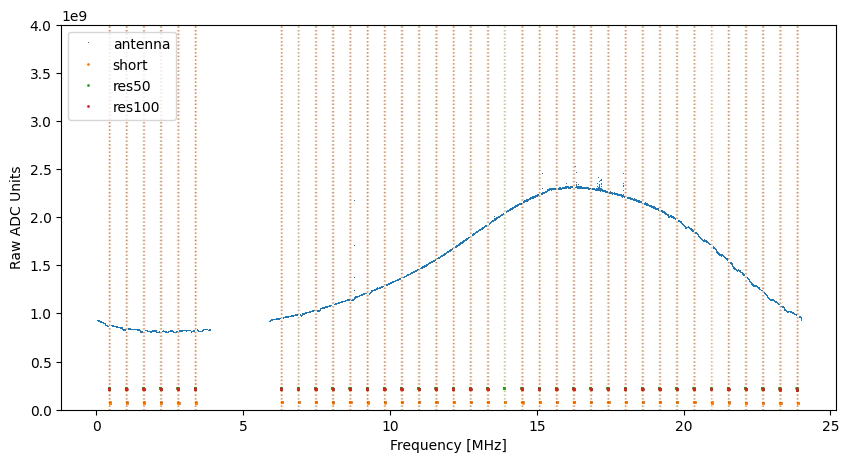

In [66]:
'''FOR THE OLD 2021 100 *EW* DATA -- the current 2021 100 NS data'''
freqind = 1225
n_day = 1

plt.figure(figsize=(10,5))
plt.plot(lst_splitant[n_day],data_splitant[n_day][:,freqind],',',label='antenna')
plt.plot(lst_splitshort[n_day],data_splitshort[n_day][:,freqind],'o',ms=1,label='short')
plt.plot(lst_splitres50[n_day],data_splitres50[n_day][:,freqind],'o',ms=1,label='res50')
plt.plot(lst_splitres100[n_day],data_splitres100[n_day][:,freqind],'o',ms=1,label='res100')
plt.vlines(lst_splitshort[n_day],ymin=0,ymax=4e9,ls=':',lw=1,alpha=0.05,color='orange')
plt.vlines(lst_splitres50[n_day],ymin=0,ymax=4e9,ls=':',lw=1,alpha=0.05,color='green')
plt.vlines(lst_splitres100[n_day],ymin=0,ymax=4e9,ls=':',lw=1,alpha=0.05,color='red')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Raw ADC Units')
plt.ylim(bottom=0,top=4e9)
plt.legend(loc='upper left')
plt.show()

In [68]:
'''Save data for future use'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
du.save_all_data(filepath,dataprep,instrument,channel,year)

### 2021, 70MHz, NS

In [48]:
year = '2021'
instrument = '70MHz'
channel = 'NS'

In [49]:
# dataprep = DataPrep(instrument, channel, year)
'''Data has been saved, load in with load_all_data()'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
dataprep = du.load_all_data(filepath,instrument,channel,year,LoadAnt=False,LoadInterpCalib=False)
print(dataprep.keys())

dict_keys(['antlst', 'antsystime', 'shortdata_meas', 'shortlst', 'shortsystime', 'res50data_meas', 'res50lst', 'res50systime', 'res100data_meas', 'res100lst', 'res100systime'])


In [ ]:
# Interpolated spectra waterfall plots

datashort = dataprep.shorts
lstshort = dataprep.lst
# print(len(lstshort[lstshort == np.nan]))

# waterfall_alldays(datashort,lstshort,freqarr,source='Short') # raw spectra

du.time_variation(datashort,lstshort,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

In [50]:
# Measured spectra waterfall plots

# Short
try:
    datashort_meas = dataprep.shorts_data
    lstshort_meas = dataprep.shorts_data_lst
except:
    print('Using saved data')
    datashort_meas = dataprep['shortdata_meas']
    lstshort_meas = dataprep['shortlst']

# du.time_variation(datashort_meas,lstshort_meas,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

# res50
try:
    datares50_meas = dataprep.res50_data
    lstres50_meas = dataprep.res50_data_lst
except:
    print('Using saved data')
    datares50_meas = dataprep['res50data_meas']
    lstres50_meas = dataprep['res50lst']

# du.time_variation(datares50_meas,lstres50_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'50 $\Omega$',plot_type='waterfall') # variation from the mean = median absolute deviation

# res100
try:
    datares100_meas = dataprep.res100_data
    lstres100_meas = dataprep.res100_data_lst
except:
    print('Using saved data')
    datares100_meas = dataprep['res100data_meas']
    lstres100_meas = dataprep['res100lst']

# du.time_variation(datares100_meas,lstres100_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'100 $\Omega$',plot_type='waterfall') # variation from the mean = median absolute deviation

Using saved data
Using saved data
Using saved data


In [51]:
# 2D plots wrt frequency
n_day = 4 # random day to check array dimensions

'''Short'''
# Prep the data
print(datashort_meas.shape)
print(lstshort_meas.shape)

# Compute median over all days, and residuals from median
time_medianshort = np.median(datashort_meas,axis=0)
res_datashort = np.abs((datashort_meas - time_medianshort)/time_medianshort)

# Split into different days
lst_splitshort, data_splitshort = du.LST_days_split(lstshort_meas,datashort_meas)
lst_splitshort, res_splitshort = du.LST_days_split(lstshort_meas,res_datashort)
systimeshort_meas_2021_70_NS = dataprep['shortsystime'] # save some data to compare with another dataset
res_datashort_2021_70_NS = res_datashort

print(len(data_splitshort)) # number of days
print(data_splitshort[n_day].shape)
print(lst_splitshort[n_day].shape)
# dimensions also check out


'''res50'''
# Prep the data
print(datares50_meas.shape)
print(lstres50_meas.shape)

# Compute median over all days, and residuals from median
time_medianres50 = np.median(datares50_meas,axis=0)
res_datares50 = np.abs((datares50_meas - time_medianres50)/time_medianres50)

# Split into different days
lst_splitres50, data_splitres50 = du.LST_days_split(lstres50_meas,datares50_meas)
lst_splitres50, res_splitres50 = du.LST_days_split(lstres50_meas,res_datares50)

print(data_splitres50[n_day].shape)
print(lst_splitres50[n_day].shape)
# dimensions also check out


'''res100'''
# Prep the data
print(datares100_meas.shape)
print(lstres100_meas.shape)

# Compute median over all days, and residuals from median
time_medianres100 = np.median(datares100_meas,axis=0)
res_datares100 = np.abs((datares100_meas - time_medianres100)/time_medianres100)

# Split into different days
lst_splitres100, data_splitres100 = du.LST_days_split(lstres100_meas,datares100_meas)
lst_splitres100, res_splitres100 = du.LST_days_split(lstres100_meas,res_datares100)

print(data_splitres100[n_day].shape)
print(lst_splitres100[n_day].shape)
# dimensions also check out

(769, 4096)
(769,)
5
(145, 4096)
(145,)
(808, 4096)
(808,)
(154, 4096)
(154,)
(797, 4096)
(797,)
(148, 4096)
(148,)


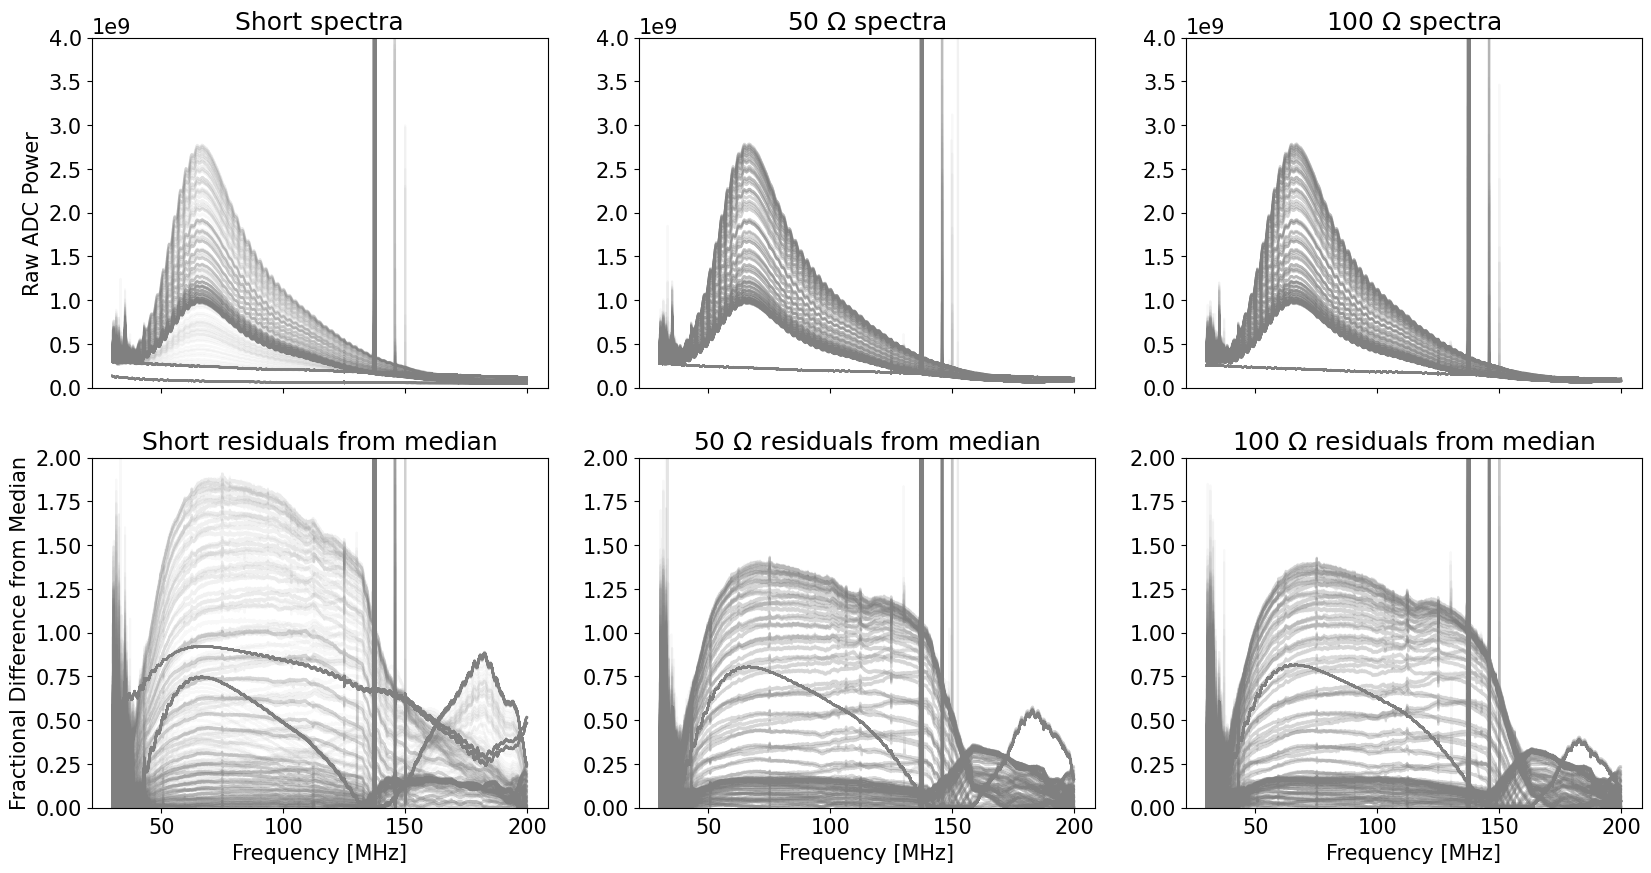

In [68]:
'''Scatter plots of raw spectra and residuals from the median over time'''
num_rows = 2
num_cals = 3 # number of calibrators

plt.rcParams.update({'font.size': 15})
plt.rc('xtick', labelsize=15) 
plt.rc('ytick', labelsize=15) 
fig, axs = plt.subplots(num_rows, num_cals, figsize=(20,10), sharex='col')
# gs = fig.add_gridspec(num_rows, num_cals)
# axs = gs.subplots(sharex='col', sharey=False)
axs = axs.flatten() # Flatten the axs array for easier iteration

# Loop through the subplots
for j in range(num_rows*num_cals):
    # Loop through days, number of days **should** be the same for all calibrators
    for n_day in range(len(data_splitshort)):
        
        # Loop through spectra, number of spectra is *not necessarily* the same for all calibrators
        
        # short spectra
        if j == 0:
            for i in range(data_splitshort[n_day].shape[0]):
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            # axs[j].set_ylim(bottom=0,top=0.5e9)
            axs[j].set_ylim(bottom=0,top=0.4e10)
            axs[j].set_ylabel('Raw ADC Power')
            axs[j].set_title('Short spectra')
            
        # res50 spectra
        if j == 1:
            for i in range(data_splitres50[n_day].shape[0]):
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            # axs[j].set_ylim(bottom=0,top=0.5e9)
            axs[j].set_ylim(bottom=0,top=0.4e10)
            axs[j].set_title(r'50 $\Omega$ spectra')
            
        # res100 spectra
        if j == 2:
            for i in range(data_splitres100[n_day].shape[0]):
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            # axs[j].set_ylim(bottom=0,top=0.5e9)
            axs[j].set_ylim(bottom=0,top=0.4e10)
            axs[j].set_title(r'100 $\Omega$ spectra')
            
        # short residuals from median    
        if j == 3:
            for i in range(res_splitshort[n_day].shape[0]):
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylim(bottom=0,top=2)
            axs[j].set_ylabel('Fractional Difference from Median')
            axs[j].set_title('Short residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
                    
        # res50 residuals from median
        if j == 4:
            for i in range(res_splitres50[n_day].shape[0]):
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylim(bottom=0,top=2)
            axs[j].set_title(r'50 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
             
        # res100 residuals from median
        if j == 5:
            for i in range(res_splitres100[n_day].shape[0]):
                axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylim(bottom=0,top=2)
            axs[j].set_title(r'100 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
            
# plt.suptitle(instrument+','+channel+','+year,fontsize=20,y=0.95)
# plt.legend()

# from matplotlib.lines import Line2D
# legend_elements = [
#     Line2D([0], [0], color='orange', lw=2, label='Flagged'),
#     Line2D([0], [0], color='grey', lw=2, label='Not flagged')
# ]
# axs[0].legend(handles=legend_elements, loc='upper right')

# plt.savefig(year+'_'+instrument+'_'+channel+'_all-calib-spectra-post-flagging.jpg',dpi=300,bbox_inches='tight')

plt.show()

In [70]:
# Getting stats on how much of the data looks messed up
# res_datashort
freqcheckarg = int(70/freqstep)
print('short:', np.sum(datashort_meas[:,freqcheckarg] > 2e8) / datashort_meas.shape[0])
print('50:', np.sum(datares50_meas[:,freqcheckarg] > 3e8) / datares50_meas.shape[0])
print('100:', np.sum(datares100_meas[:,freqcheckarg] > 3e8) / datares100_meas.shape[0])

short: 0.811443433029909
50: 0.8094059405940595
100: 0.8143036386449184


In [28]:
# Plotting antenna data over LST for a certain day at a certain frequency
# Load the antenna data
ant_data = dataprep.antenna
ant_lst = dataprep.lst

# Split the antenna data
lst_splitant, data_splitant = du.LST_days_split(ant_lst,ant_data)
print(len(lst_splitant))
print(data_splitant[2].shape)

5
(11205, 4096)


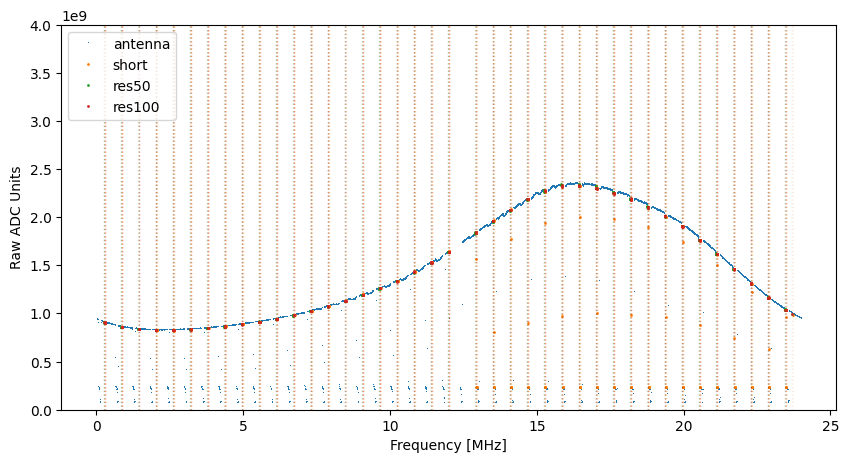

In [56]:
freqind = 1225
n_day = 1

plt.figure(figsize=(10,5))
plt.plot(lst_splitant[n_day],data_splitant[n_day][:,freqind],',',label='antenna')
plt.plot(lst_splitshort[n_day],data_splitshort[n_day][:,freqind],'o',ms=1,label='short')
plt.plot(lst_splitres50[n_day],data_splitres50[n_day][:,freqind],'o',ms=1,label='res50')
plt.plot(lst_splitres100[n_day],data_splitres100[n_day][:,freqind],'o',ms=1,label='res100')
plt.vlines(lst_splitshort[n_day],ymin=0,ymax=4e9,ls=':',lw=1,alpha=0.05,color='orange')
plt.vlines(lst_splitres50[n_day],ymin=0,ymax=4e9,ls=':',lw=1,alpha=0.05,color='green')
plt.vlines(lst_splitres100[n_day],ymin=0,ymax=4e9,ls=':',lw=1,alpha=0.05,color='red')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Raw ADC Units')
plt.ylim(bottom=0,top=4e9)
plt.legend(loc='upper left')
plt.show()

In [58]:
'''Save data for future use'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
du.save_all_data(filepath,dataprep,instrument,channel,year)

### 2018, 100MHz, EW

In [14]:
year = '2018'
instrument = '100MHz'
channel = 'EW'

In [15]:
# dataprep = DataPrep(instrument, channel, year)
'''Data has been saved, load in with load_all_data()'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
dataprep = du.load_all_data(filepath,instrument,channel,year,LoadAnt=False,LoadInterpCalib=False)
print(dataprep.keys())

dict_keys(['antlst', 'antsystime', 'shortdata_meas', 'shortlst', 'shortsystime', 'res50data_meas', 'res50lst', 'res50systime', 'res100data_meas', 'res100lst', 'res100systime'])


In [ ]:
# Interpolated spectra waterfall plots

datashort = dataprep.shorts
lstshort = dataprep.lst
# print(len(lstshort[lstshort == np.nan]))

# waterfall_alldays(datashort,lstshort,freqarr,source='Short') # raw spectra

du.time_variation(datashort,lstshort,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

In [16]:
# Measured spectra waterfall plots

# Short
try:
    datashort_meas = dataprep.shorts_data
    lstshort_meas = dataprep.shorts_data_lst
except:
    print('Using saved data')
    datashort_meas = dataprep['shortdata_meas']
    lstshort_meas = dataprep['shortlst']

# du.time_variation(datashort_meas,lstshort_meas,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

# res50
try:
    datares50_meas = dataprep.res50_data
    lstres50_meas = dataprep.res50_data_lst
except:
    print('Using saved data')
    datares50_meas = dataprep['res50data_meas']
    lstres50_meas = dataprep['res50lst']

# du.time_variation(datares50_meas,lstres50_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'50 $\Omega$',plot_type='waterfall') # variation from the mean = median absolute deviation

# res100
try:
    datares100_meas = dataprep.res100_data
    lstres100_meas = dataprep.res100_data_lst
except:
    print('Using saved data')
    datares100_meas = dataprep['res100data_meas']
    lstres100_meas = dataprep['res100lst']

# du.time_variation(datares100_meas,lstres100_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'100 $\Omega$',plot_type='waterfall') # variation from the mean = median absolute deviation

Using saved data
Using saved data
Using saved data


In [17]:
# 2D plots wrt frequency
n_day = 4 # random day to check array dimensions

'''Short'''
# Prep the data
print(datashort_meas.shape)
print(lstshort_meas.shape)

# Compute median over all days, and residuals from median
time_medianshort = np.median(datashort_meas,axis=0)
res_datashort = np.abs((datashort_meas - time_medianshort)/time_medianshort)
systimeshort_meas_2018_100_EW = dataprep['shortsystime'] # save some data to compare with another dataset
res_datashort_2018_100_EW = res_datashort

# Split into different days
lst_splitshort, data_splitshort = du.LST_days_split(lstshort_meas,datashort_meas)
lst_splitshort, res_splitshort = du.LST_days_split(lstshort_meas,res_datashort)

print(len(data_splitshort)) # number of days
print(data_splitshort[n_day].shape)
print(lst_splitshort[n_day].shape)
# dimensions also check out


'''res50'''
# Prep the data
print(datares50_meas.shape)
print(lstres50_meas.shape)

# Compute median over all days, and residuals from median
time_medianres50 = np.median(datares50_meas,axis=0)
res_datares50 = np.abs((datares50_meas - time_medianres50)/time_medianres50)

# Split into different days
lst_splitres50, data_splitres50 = du.LST_days_split(lstres50_meas,datares50_meas)
lst_splitres50, res_splitres50 = du.LST_days_split(lstres50_meas,res_datares50)

print(data_splitres50[n_day].shape)
print(lst_splitres50[n_day].shape)
# dimensions also check out


'''res100'''
# Prep the data
print(datares100_meas.shape)
print(lstres100_meas.shape)

# Compute median over all days, and residuals from median
time_medianres100 = np.median(datares100_meas,axis=0)
res_datares100 = np.abs((datares100_meas - time_medianres100)/time_medianres100)

# Split into different days
lst_splitres100, data_splitres100 = du.LST_days_split(lstres100_meas,datares100_meas)
lst_splitres100, res_splitres100 = du.LST_days_split(lstres100_meas,res_datares100)

print(data_splitres100[n_day].shape)
print(lst_splitres100[n_day].shape)
# dimensions also check out

(3855, 4096)
(3855,)
32
(34, 4096)
(34,)
(3934, 4096)
(3934,)
(37, 4096)
(37,)
(3882, 4096)
(3882,)
(33, 4096)
(33,)


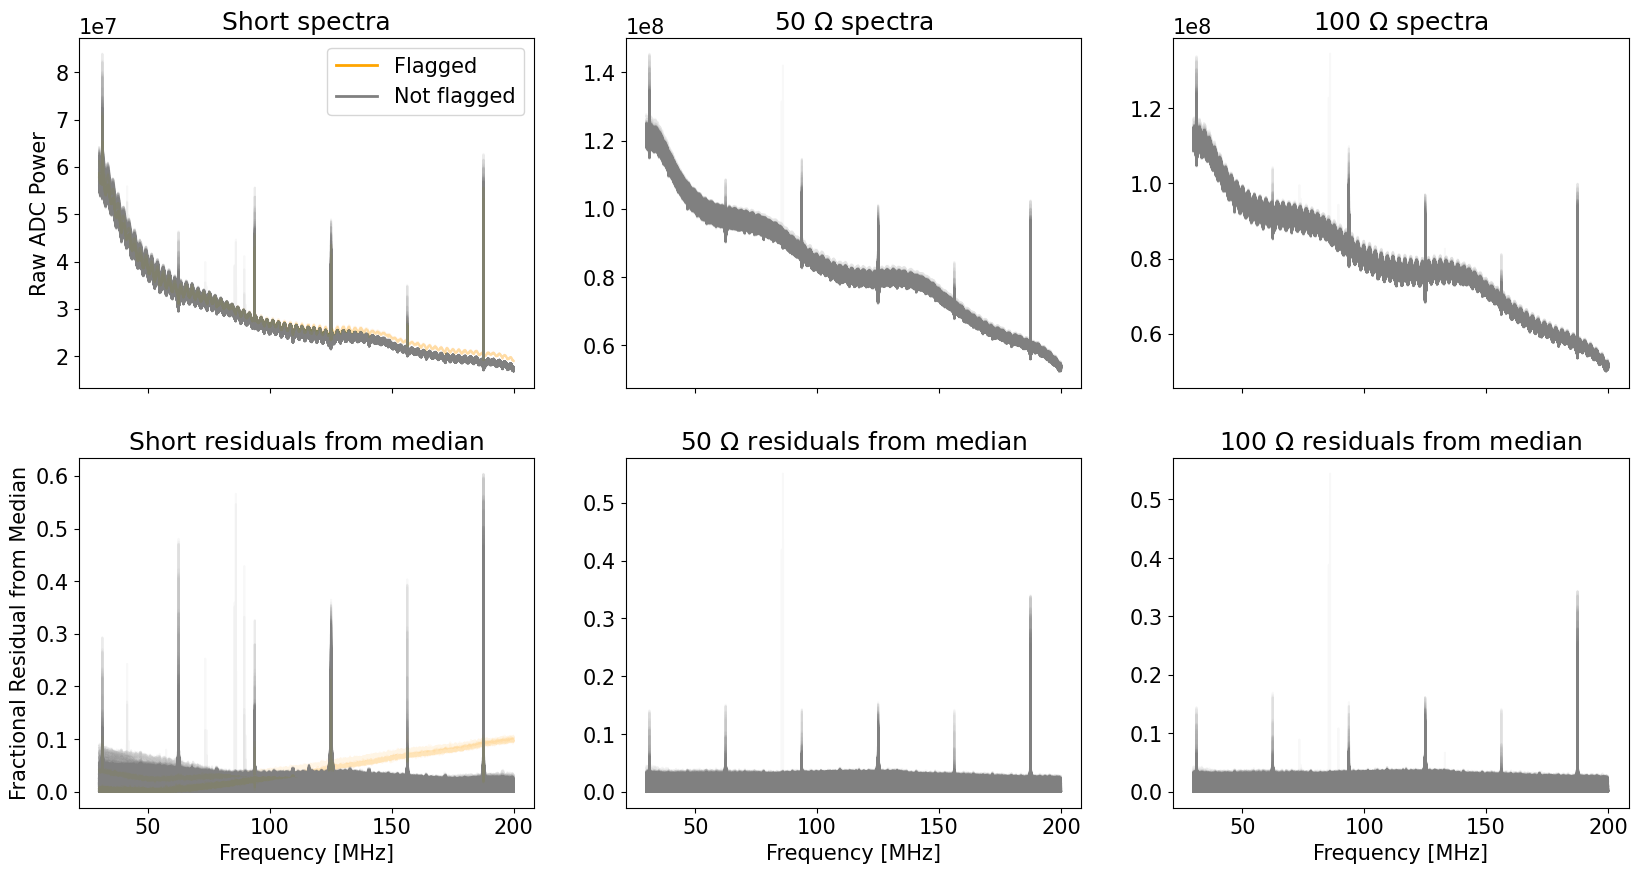

There are 8 bad short spectra, that is 0.20752269779507135 % of the short spectra.


In [18]:
'''Scatter plots of raw spectra and residuals from the median over time'''
num_rows = 2
num_cals = 3 # number of calibrators

plt.rcParams.update({'font.size': 15})
plt.rc('xtick', labelsize=15) 
plt.rc('ytick', labelsize=15) 
fig, axs = plt.subplots(num_rows, num_cals, figsize=(20,10), sharex='col')
# gs = fig.add_gridspec(num_rows, num_cals)
# axs = gs.subplots(sharex='col', sharey=False)
axs = axs.flatten() # Flatten the axs array for easier iteration

# Count how many weird short spectra there are
countsh = 0
# Count how many total short spectra there are
nspectra = 0

# Testing:
# for n_day in range(len(data_splitshort)):
#     nspectra += data_splitshort[n_day].shape[0]

# Loop through the subplots
for j in range(num_rows*num_cals):
    # Loop through days, number of days **should** be the same for all calibrators
    for n_day in range(len(data_splitshort)):
        
        # Loop through spectra, number of spectra is *not necessarily* the same for all calibrators
        
        # short spectra
        if j == 0:
            for i in range(data_splitshort[n_day].shape[0]):
                if res_splitshort[n_day][i,maxfreqarg] >= 0.05:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                else:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylabel('Raw ADC Power')
            axs[j].set_title('Short spectra')
            # axs[j].legend(loc='upper right')
        
        # res50 spectra
        if j == 1:
            for i in range(data_splitres50[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'50 $\Omega$ spectra')
            
        # res100 spectra
        if j == 2:
            for i in range(data_splitres100[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'100 $\Omega$ spectra')
            
        # short residuals from median    
        if j == 3:
            nspectra += data_splitshort[n_day].shape[0]
            # print('Short odd spectra:')
            for i in range(res_splitshort[n_day].shape[0]): 
                if res_splitshort[n_day][i,maxfreqarg] >= 0.05:
                    # print('day',n_day,'LST',lst_splitshort[n_day][i],'LSTi',i) # printing out which spectra constitute the weird one(s)
                    countsh += 1
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                else:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylabel('Fractional Residual from Median')
            axs[j].set_title('Short residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
                    
        # res50 residuals from median
        if j == 4:
            # print('Res50 odd spectra:')
            for i in range(res_splitres50[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        # print('day',n_day,'LST',lst_splitres50[n_day][i],'LSTi',i)
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'50 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
             
        # res100 residuals from median
        if j == 5:
            # print('Res100 odd spectra:')
            for i in range(res_splitres100[n_day].shape[0]):
                try:
                    # if res_splitshort[n_day][i,maxfreqarg] >= 0.03: # change to this statement to color the spectra that correspond to flagged short spectra
                    if False:
                        # print('day',n_day,'LST',lst_splitres100[n_day][i],'LSTi',i)
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'100 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
            
# plt.suptitle(instrument+','+channel+','+year,fontsize=20,y=0.95)


from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='orange', lw=2, label='Flagged'),
    Line2D([0], [0], color='grey', lw=2, label='Not flagged')
]
axs[0].legend(handles=legend_elements, loc='upper right')

plt.savefig(year+'_'+instrument+'_'+channel+'_all-calib-spectra-post-flagging.jpg',dpi=300,bbox_inches='tight')
plt.show()

print('There are',countsh,'bad short spectra, that is',countsh/nspectra*100,'% of the short spectra.') # need to implement a percentage too

In [12]:
'''Save data for future use'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
du.save_all_data(filepath,dataprep,instrument,channel,year)

### 2018, 70 MHz, EW

In [78]:
year = '2018'
instrument = '70MHz'
channel = 'EW'

In [79]:
# dataprep = DataPrep(instrument, channel, year)
'''Data has been saved, load in with load_all_data()'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
dataprep = du.load_all_data(filepath,instrument,channel,year,LoadAnt=False,LoadInterpCalib=False)
print(dataprep.keys())

dict_keys(['antlst', 'antsystime', 'shortdata_meas', 'shortlst', 'shortsystime', 'res50data_meas', 'res50lst', 'res50systime', 'res100data_meas', 'res100lst', 'res100systime'])


In [ ]:
# Interpolated spectra waterfall plots

datashort = dataprep.shorts
lstshort = dataprep.lst
# print(len(lstshort[lstshort == np.nan]))

# waterfall_alldays(datashort,lstshort,freqarr,source='Short') # raw spectra

du.time_variation(datashort,lstshort,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

In [80]:
# Measured spectra waterfall plots

# Short
try:
    datashort_meas = dataprep.shorts_data
    lstshort_meas = dataprep.shorts_data_lst
except:
    print('Using saved data')
    datashort_meas = dataprep['shortdata_meas']
    lstshort_meas = dataprep['shortlst']

# du.time_variation(datashort_meas,lstshort_meas,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

# res50
try:
    datares50_meas = dataprep.res50_data
    lstres50_meas = dataprep.res50_data_lst
except:
    print('Using saved data')
    datares50_meas = dataprep['res50data_meas']
    lstres50_meas = dataprep['res50lst']

# du.time_variation(datares50_meas,lstres50_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'50 $\Omega$',plot_type='waterfall') # variation from the mean = median absolute deviation

# res100
try:
    datares100_meas = dataprep.res100_data
    lstres100_meas = dataprep.res100_data_lst
except:
    print('Using saved data')
    datares100_meas = dataprep['res100data_meas']
    lstres100_meas = dataprep['res100lst']

# du.time_variation(datares100_meas,lstres100_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'100 $\Omega$',plot_type='waterfall') # variation from the mean = median absolute deviation

Using saved data
Using saved data
Using saved data


In [81]:
# 2D plots wrt frequency
n_day = 4 # random day to check array dimensions

'''Short'''
# Prep the data
print(datashort_meas.shape)
print(lstshort_meas.shape)

# Compute median over all days, and residuals from median
time_medianshort = np.median(datashort_meas,axis=0)
res_datashort = np.abs((datashort_meas - time_medianshort)/time_medianshort)
systimeshort_meas_2018_70_EW = dataprep['shortsystime'] # save some data to compare with another dataset
res_datashort_2018_70_EW = res_datashort

# Split into different days
lst_splitshort, data_splitshort = du.LST_days_split(lstshort_meas,datashort_meas)
lst_splitshort, res_splitshort = du.LST_days_split(lstshort_meas,res_datashort)

print(len(data_splitshort)) # number of days
print(data_splitshort[n_day].shape)
print(lst_splitshort[n_day].shape)
# dimensions also check out


'''res50'''
# Prep the data
print(datares50_meas.shape)
print(lstres50_meas.shape)

# Compute median over all days, and residuals from median
time_medianres50 = np.median(datares50_meas,axis=0)
res_datares50 = np.abs((datares50_meas - time_medianres50)/time_medianres50)
systimeres50_meas_2018_70_EW = dataprep['res50systime'] # save some data to compare with another dataset
res_datares50_2018_70_EW = res_datares50

# Split into different days
lst_splitres50, data_splitres50 = du.LST_days_split(lstres50_meas,datares50_meas)
lst_splitres50, res_splitres50 = du.LST_days_split(lstres50_meas,res_datares50)

print(data_splitres50[n_day].shape)
print(lst_splitres50[n_day].shape)
# dimensions also check out


'''res100'''
# Prep the data
print(datares100_meas.shape)
print(lstres100_meas.shape)

# Compute median over all days, and residuals from median
time_medianres100 = np.median(datares100_meas,axis=0)
res_datares100 = np.abs((datares100_meas - time_medianres100)/time_medianres100)
systimeres100_meas_2018_70_EW = dataprep['res100systime'] # save some data to compare with another dataset
res_datares100_2018_70_EW = res_datares100

# Split into different days
lst_splitres100, data_splitres100 = du.LST_days_split(lstres100_meas,datares100_meas)
lst_splitres100, res_splitres100 = du.LST_days_split(lstres100_meas,res_datares100)

print(data_splitres100[n_day].shape)
print(lst_splitres100[n_day].shape)
# dimensions also check out

(5152, 4096)
(5152,)
41
(44, 4096)
(44,)
(5207, 4096)
(5207,)
(52, 4096)
(52,)
(5272, 4096)
(5272,)
(46, 4096)
(46,)


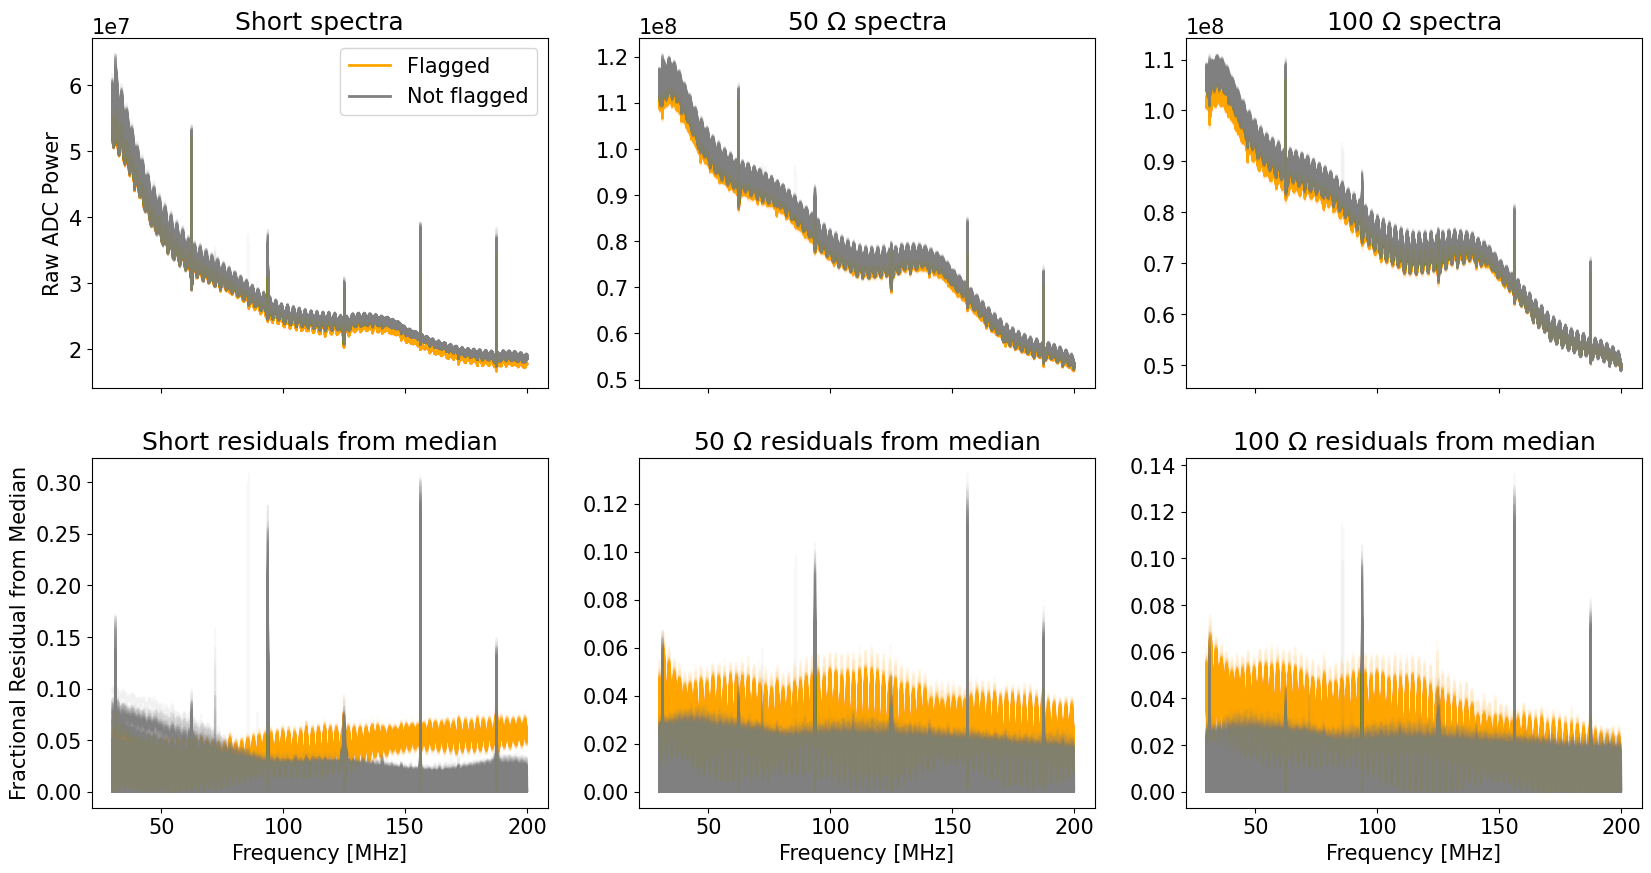

There are 544 bad short spectra, that is 10.559006211180124 % of the short spectra.


In [154]:
'''Scatter plots of raw spectra and residuals from the median over time'''
num_rows = 2
num_cals = 3 # number of calibrators

plt.rcParams.update({'font.size': 15})
plt.rc('xtick', labelsize=15) 
plt.rc('ytick', labelsize=15) 
fig, axs = plt.subplots(num_rows, num_cals, figsize=(20,10), sharex='col')
# gs = fig.add_gridspec(num_rows, num_cals)
# axs = gs.subplots(sharex='col', sharey=False)
axs = axs.flatten() # Flatten the axs array for easier iteration

# Count how many weird short spectra there are
countsh = 0
# Count how many total short spectra there are
nspectra = 0

# Testing:
# for n_day in range(len(data_splitshort)):
#     nspectra += data_splitshort[n_day].shape[0]

# Loop through the subplots
for j in range(num_rows*num_cals):
    # Loop through days, number of days **should** be the same for all calibrators
    for n_day in range(len(data_splitshort)):
        
        # Loop through spectra, number of spectra is *not necessarily* the same for all calibrators
        
        # short spectra
        if j == 0:
            for i in range(data_splitshort[n_day].shape[0]):
                if res_splitshort[n_day][i,maxfreqarg] >= 0.03:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                else:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylabel('Raw ADC Power')
            axs[j].set_title('Short spectra')
            # axs[j].legend(loc='upper right')
        
        # res50 spectra
        if j == 1:
            for i in range(data_splitres50[n_day].shape[0]):
                try:
                    if res_splitres50[n_day][i,int(100/freqstep)] >= 0.03:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'50 $\Omega$ spectra')
            
        # res100 spectra
        if j == 2:
            for i in range(data_splitres100[n_day].shape[0]):
                try:
                    if res_splitres100[n_day][i,minfreqarg] >= 0.03:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'100 $\Omega$ spectra')
            
        # short residuals from median    
        if j == 3:
            nspectra += data_splitshort[n_day].shape[0]
            # print('Short odd spectra:')
            for i in range(res_splitshort[n_day].shape[0]): 
                if res_splitshort[n_day][i,maxfreqarg] >= 0.03:
                    # print('day',n_day,'LST',lst_splitshort[n_day][i],'LSTi',i) # printing out which spectra constitute the weird one(s)
                    countsh += 1
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                else:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylabel('Fractional Residual from Median')
            axs[j].set_title('Short residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
                    
        # res50 residuals from median
        if j == 4:
            # print('Res50 odd spectra:')
            for i in range(res_splitres50[n_day].shape[0]):
                try:
                    if res_splitres50[n_day][i,int(100/freqstep)] >= 0.03:
                        # print('day',n_day,'LST',lst_splitres50[n_day][i],'LSTi',i)
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'50 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
             
        # res100 residuals from median
        if j == 5:
            # print('Res100 odd spectra:')
            for i in range(res_splitres100[n_day].shape[0]):
                try:
                    if res_splitres100[n_day][i,minfreqarg] >= 0.03:
                        # print('day',n_day,'LST',lst_splitres100[n_day][i],'LSTi',i)
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'100 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
            
# plt.suptitle(instrument+','+channel+','+year,fontsize=20,y=0.95)


from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='orange', lw=2, label='Flagged'),
    Line2D([0], [0], color='grey', lw=2, label='Not flagged')
]
axs[0].legend(handles=legend_elements, loc='upper right')

plt.savefig(year+'_'+instrument+'_'+channel+'_all-calib-spectra-post-flagging.jpg',dpi=300,bbox_inches='tight')
plt.show()

print('There are',countsh,'bad short spectra, that is',countsh/nspectra*100,'% of the short spectra.') # need to implement a percentage too

In [22]:
'''Save data for future use'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
du.save_all_data(filepath,dataprep,instrument,channel,year)

### 2018, 70 MHz, NS

In [60]:
year = '2018'
instrument = '70MHz'
channel = 'NS'

In [61]:
# dataprep = DataPrep(instrument, channel, year)
# fileend = '_'+year+'_'+instrument+'_'+channel+'.npy' # re-saving the res100 data i accidentally deleted
# datares100_meas = dataprep.res100_data
# np.save(filepath+'res100data_meas'+fileend,datares100_meas)
'''Data has been saved, load in with load_all_data()'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
dataprep = du.load_all_data(filepath,instrument,channel,year,LoadAnt=False,LoadInterpCalib=False)
print(dataprep.keys())

dict_keys(['antlst', 'antsystime', 'shortdata_meas', 'shortlst', 'shortsystime', 'res50data_meas', 'res50lst', 'res50systime', 'res100data_meas', 'res100lst', 'res100systime'])


In [ ]:
# Interpolated spectra waterfall plots

datashort = dataprep.shorts
lstshort = dataprep.lst
# print(len(lstshort[lstshort == np.nan]))

# waterfall_alldays(datashort,lstshort,freqarr,source='Short') # raw spectra

du.time_variation(datashort,lstshort,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

In [62]:
# Measured spectra waterfall plots

# Short
try:
    datashort_meas = dataprep.shorts_data
    lstshort_meas = dataprep.shorts_data_lst
except:
    print('Using saved data')
    datashort_meas = dataprep['shortdata_meas']
    lstshort_meas = dataprep['shortlst']

# du.time_variation(datashort_meas,lstshort_meas,freqarr,year=year,instrument=instrument,channel=channel,source='Short',plot_type='waterfall') # variation from the mean = median absolute deviation

# res50
try:
    datares50_meas = dataprep.res50_data
    lstres50_meas = dataprep.res50_data_lst
except:
    print('Using saved data')
    datares50_meas = dataprep['res50data_meas']
    lstres50_meas = dataprep['res50lst']

# du.time_variation(datares50_meas,lstres50_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'50 $\Omega$',plot_type='waterfall') # variation from the mean = median absolute deviation

# res100
try:
    datares100_meas = dataprep.res100_data
    lstres100_meas = dataprep.res100_data_lst
except:
    print('Using saved data')
    datares100_meas = dataprep['res100data_meas']
    lstres100_meas = dataprep['res100lst']

# du.time_variation(datares100_meas,lstres100_meas,freqarr,year=year,instrument=instrument,channel=channel,source=r'100 $\Omega$',plot_type='waterfall') # variation from the mean = median absolute deviation

Using saved data
Using saved data
Using saved data


In [63]:
# 2D plots wrt frequency
n_day = 1 # random day to check array dimensions

'''Short'''
# Prep the data
print(datashort_meas.shape)
print(lstshort_meas.shape)

# Compute median over all days, and residuals from median
time_medianshort = np.median(datashort_meas,axis=0)
res_datashort = np.abs((datashort_meas - time_medianshort)/time_medianshort)

# Split into different days
lst_splitshort, data_splitshort = du.LST_days_split(lstshort_meas,datashort_meas)
lst_splitshort, res_splitshort = du.LST_days_split(lstshort_meas,res_datashort)
systimeshort_meas_2018_70_NS = dataprep['shortsystime'] # save some data to compare with another dataset
res_datashort_2018_70_NS = res_datashort

print(len(data_splitshort)) # number of days
# print(data_splitshort[n_day].shape)
# print(lst_splitshort[n_day].shape)
# dimensions also check out


'''res50'''
# Prep the data
print(datares50_meas.shape)
print(lstres50_meas.shape)

# Compute median over all days, and residuals from median
time_medianres50 = np.median(datares50_meas,axis=0)
res_datares50 = np.abs((datares50_meas - time_medianres50)/time_medianres50)
systimeres50_meas_2018_70_NS = dataprep['res50systime'] # save some data to compare with another dataset
res_datares50_2018_70_NS = res_datares50

# Split into different days
lst_splitres50, data_splitres50 = du.LST_days_split(lstres50_meas,datares50_meas)
lst_splitres50, res_splitres50 = du.LST_days_split(lstres50_meas,res_datares50)

# print(data_splitres50[n_day].shape)
# print(lst_splitres50[n_day].shape)
# dimensions also check out


'''res100'''
# Prep the data
print(datares100_meas.shape)
print(lstres100_meas.shape)

# Compute median over all days, and residuals from median
time_medianres100 = np.median(datares100_meas,axis=0)
res_datares100 = np.abs((datares100_meas - time_medianres100)/time_medianres100)
systimeres100_meas_2018_70_NS = dataprep['res100systime'] # save some data to compare with another dataset
res_datares100_2018_70_NS = res_datares100

# Split into different days
lst_splitres100, data_splitres100 = du.LST_days_split(lstres100_meas,datares100_meas)
lst_splitres100, res_splitres100 = du.LST_days_split(lstres100_meas,res_datares100)

# print(data_splitres100[n_day].shape)
# print(lst_splitres100[n_day].shape)
# dimensions also check out

(305, 4096)
(305,)
2
(297, 4096)
(297,)
(292, 4096)
(292,)


Short odd spectra:
day 0 LST 22.67544280924929 LSTi 113
day 0 LST 22.67784247671887 LSTi 114
day 0 LST 22.680209356718294 LSTi 115
day 0 LST 22.682624542407158 LSTi 116
day 0 LST 22.685001407187272 LSTi 117
day 0 LST 22.90991700322629 LSTi 118
day 0 LST 22.91231393110406 LSTi 119
day 0 LST 22.9146716640682 LSTi 120
day 0 LST 22.917084852216263 LSTi 121
day 0 LST 22.9194688154221 LSTi 122
Short odd spectra:
day 1 LST 0.08593578808944673 LSTi 0
day 1 LST 0.0895646974872448 LSTi 1
day 1 LST 0.09315639961716435 LSTi 2
day 1 LST 0.32044326310202287 LSTi 3
day 1 LST 0.3240584199545858 LSTi 4
day 1 LST 0.3276896094946302 LSTi 5
day 1 LST 0.5549434791107097 LSTi 6
day 1 LST 0.5585449738002155 LSTi 7
day 1 LST 0.5621503064810787 LSTi 8
day 1 LST 0.793047877101636 LSTi 9
day 1 LST 0.7965264960361742 LSTi 10
day 1 LST 1.0274364401580316 LSTi 11
day 1 LST 1.0310694474023792 LSTi 12
day 1 LST 1.2619197021217836 LSTi 13
day 1 LST 1.2655297372342313 LSTi 14
day 1 LST 1.496437395436155 LSTi 15
day 1 L

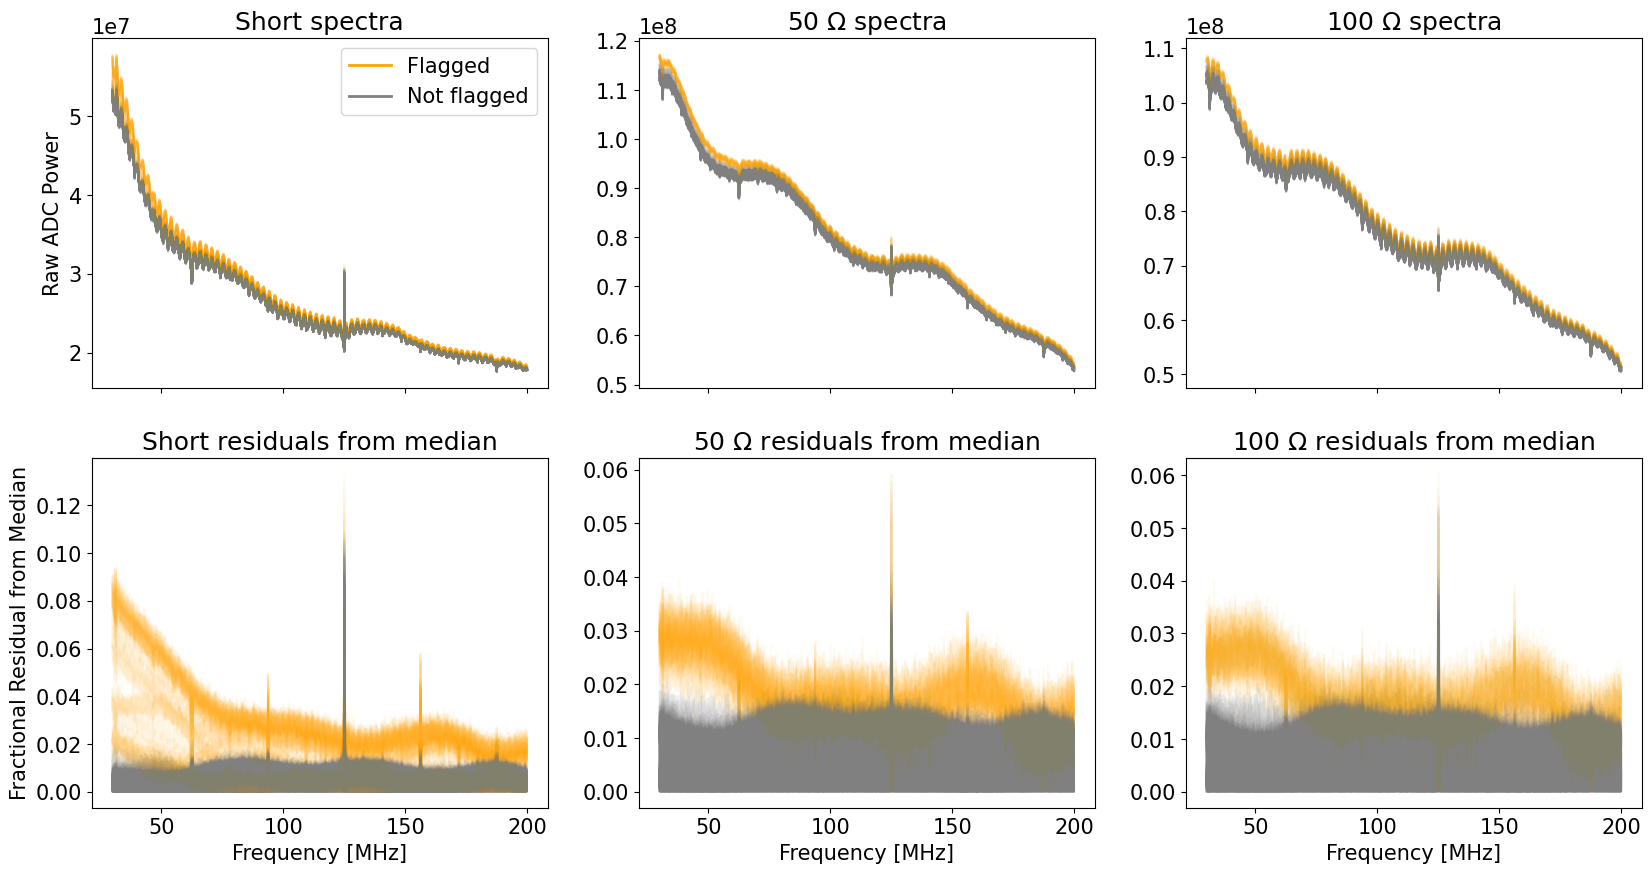

There are 62 bad short spectra, that is 20.327868852459016 % of the short spectra.


In [93]:
'''Scatter plots of raw spectra and residuals from the median over time'''
num_rows = 2
num_cals = 3 # number of calibrators

plt.rcParams.update({'font.size': 15})
plt.rc('xtick', labelsize=15) 
plt.rc('ytick', labelsize=15) 
fig, axs = plt.subplots(num_rows, num_cals, figsize=(20,10), sharex='col')
# gs = fig.add_gridspec(num_rows, num_cals)
# axs = gs.subplots(sharex='col', sharey=False)
axs = axs.flatten() # Flatten the axs array for easier iteration

# Count how many weird short spectra there are
countsh = 0
# Count how many total short spectra there are
nspectra = 0

# Testing:
# for n_day in range(len(data_splitshort)):
#     nspectra += data_splitshort[n_day].shape[0]

# Loop through the subplots
for j in range(num_rows*num_cals):
    # Loop through days, number of days **should** be the same for all calibrators
    for n_day in range(len(data_splitshort)):
        
        # Loop through spectra, number of spectra is *not necessarily* the same for all calibrators
        
        # short spectra
        if j == 0:
            for i in range(data_splitshort[n_day].shape[0]):
                if res_splitshort[n_day][i,minfreqarg] >= 0.015:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                else:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylabel('Raw ADC Power')
            axs[j].set_title('Short spectra')
            # axs[j].legend(loc='upper right')
        
        # res50 spectra
        if j == 1:
            for i in range(data_splitres50[n_day].shape[0]):
                try:
                    if res_splitres50[n_day][i,minfreqarg] >= 0.019:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'50 $\Omega$ spectra')
            
        # res100 spectra
        if j == 2:
            for i in range(data_splitres100[n_day].shape[0]):
                try:
                    if res_splitres100[n_day][i,minfreqarg] >= 0.022:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],data_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'100 $\Omega$ spectra')
            
        # short residuals from median    
        if j == 3:
            nspectra += data_splitshort[n_day].shape[0]
            print('Short odd spectra:')
            for i in range(res_splitshort[n_day].shape[0]): 
                if res_splitshort[n_day][i,minfreqarg] >= 0.015:
                    print('day',n_day,'LST',lst_splitshort[n_day][i],'LSTi',i) # printing out which spectra constitute the weird one(s)
                    countsh += 1
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                else:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_ylabel('Fractional Residual from Median')
            axs[j].set_title('Short residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
                    
        # res50 residuals from median
        if j == 4:
            print('Res50 odd spectra:')
            for i in range(res_splitres50[n_day].shape[0]):
                try:
                    if res_splitres50[n_day][i,minfreqarg] >= 0.019:
                        print('day',n_day,'LST',lst_splitres50[n_day][i],'LSTi',i)
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres50[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'50 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
             
        # res100 residuals from median
        if j == 5:
            print('Res100 odd spectra:')
            for i in range(res_splitres100[n_day].shape[0]):
                try:
                    if res_splitres100[n_day][i,minfreqarg] >= 0.022:
                        print('day',n_day,'LST',lst_splitres100[n_day][i],'LSTi',i)
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
                    else:
                        axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
                except:
                    axs[j].plot(freqarr[minfreqarg:maxfreqarg],res_splitres100[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)
            axs[j].set_title(r'100 $\Omega$ residuals from median')
            axs[j].set_xlabel('Frequency [MHz]')
            
# plt.suptitle(instrument+','+channel+','+year,fontsize=20,y=0.95)


from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='orange', lw=2, label='Flagged'),
    Line2D([0], [0], color='grey', lw=2, label='Not flagged')
]
axs[0].legend(handles=legend_elements, loc='upper right')

plt.savefig(year+'_'+instrument+'_'+channel+'_all-calib-spectra-post-flagging.jpg',dpi=300,bbox_inches='tight')
plt.show()

print('There are',countsh,'bad short spectra, that is',countsh/nspectra*100,'% of the short spectra.') # need to implement a percentage too

In [91]:
# Getting stats on how much of the data looks messed up
# res_datashort
freqcheckarg = minfreqarg
print('short:', np.sum(res_datashort[:,freqcheckarg] > 0.015) / res_datashort.shape[0])
print('50:', np.sum(res_datares50[:,freqcheckarg] > 0.019) / res_datares50.shape[0])
print('100:', np.sum(res_datares100[:,freqcheckarg] > 0.022) / res_datares100.shape[0])

short: 0.20327868852459016
50: 0.12794612794612795
100: 0.1095890410958904


In [39]:
'''Save data for future use'''
filepath = '/home/s/sievers/lauriea/test_data/'+year+'/'+instrument+'/'+channel+'/'
du.save_all_data(filepath,dataprep,instrument,channel,year)

In [44]:
loaded_data = du.load_all_data(filepath,instrument,channel,year)

## Flagging summary plot

2021_70_NS 100.0 %
2021_70_EW 5.019697547337654 %
2021_100_NS 17.91677049588836 %
2021_100_EW 0.06806028196402528 %
2018_70_NS_short 20.327868852459016 %
2018_70_NS_res50 12.794612794612794 %
2018_70_NS_res100 10.95890410958904 %
2018_70_EW_short 10.559006211180124 %
2018_70_EW_res50 10.485884386402919 %
2018_70_EW_res100 10.41350531107739 %
2018_100_NS 1.9783698232656293 %
2018_100_EW 0.20752269779507135 %


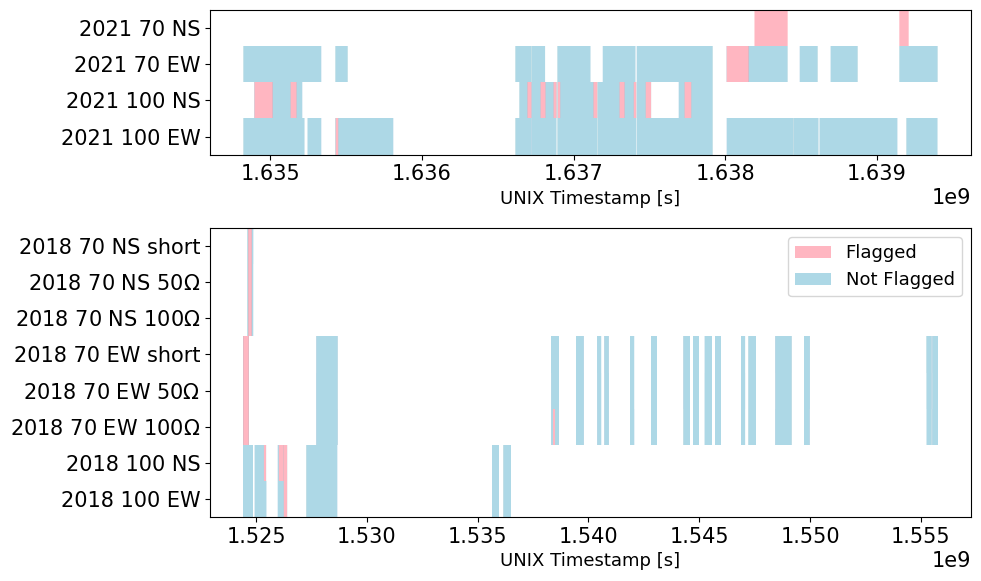

In [71]:
# Comparing times of flagged spectra
systf_2021_70_NS = systimeshort_meas_2021_70_NS # all flagged
print('2021_70_NS',len(systf_2021_70_NS)/len(systimeshort_meas_2021_70_NS)*100,'%')
systf_2021_70_EW = systimeshort_meas_2021_70_EW[res_datashort_2021_70_EW[:,minfreqarg] >= 0.15]
print('2021_70_EW',len(systf_2021_70_EW)/len(systimeshort_meas_2021_70_EW)*100,'%')
systf_2021_100_NS = systimeshort_meas_2021_100_NS[res_datashort_2021_100_NS[:,maxfreqarg] >= 0.03]
print('2021_100_NS',len(systf_2021_100_NS)/len(systimeshort_meas_2021_100_NS)*100,'%')
systf_2021_100_EW = systimeshort_meas_2021_100_EW[res_datashort_2021_100_EW[:,maxfreqarg] >= 0.15]
print('2021_100_EW',len(systf_2021_100_EW)/len(systimeshort_meas_2021_100_EW)*100,'%')

systf_2018_70_NS_short = systimeshort_meas_2018_70_NS[res_datashort_2018_70_NS[:,minfreqarg] >= 0.015]
print('2018_70_NS_short',len(systf_2018_70_NS_short)/len(systimeshort_meas_2018_70_NS)*100,'%')
systf_2018_70_NS_res50 = systimeres50_meas_2018_70_NS[res_datares50_2018_70_NS[:,minfreqarg] >= 0.019]
print('2018_70_NS_res50',len(systf_2018_70_NS_res50)/len(systimeres50_meas_2018_70_NS)*100,'%')
systf_2018_70_NS_res100 = systimeres100_meas_2018_70_NS[res_datares100_2018_70_NS[:,minfreqarg] >= 0.022]
print('2018_70_NS_res100',len(systf_2018_70_NS_res100)/len(systimeres100_meas_2018_70_NS)*100,'%')


systf_2018_70_EW_short = systimeshort_meas_2018_70_EW[res_datashort_2018_70_EW[:,maxfreqarg] >= 0.03]
print('2018_70_EW_short',len(systf_2018_70_EW_short)/len(systimeshort_meas_2018_70_EW)*100,'%')
systf_2018_70_EW_res50 = systimeres50_meas_2018_70_EW[res_datares50_2018_70_EW[:,int(100/freqstep)] >= 0.03]
print('2018_70_EW_res50',len(systf_2018_70_EW_res50)/len(systimeres50_meas_2018_70_EW)*100,'%')
systf_2018_70_EW_res100 = systimeres100_meas_2018_70_EW[res_datares100_2018_70_EW[:,minfreqarg] >= 0.03]
print('2018_70_EW_res100',len(systf_2018_70_EW_res100)/len(systimeres100_meas_2018_70_EW)*100,'%')


systf_2018_100_NS = systimeshort_meas_2018_100_NS[res_datashort_2018_100_NS[:,maxfreqarg] >= 0.09]
print('2018_100_NS',len(systf_2018_100_NS)/len(systimeshort_meas_2018_100_NS)*100,'%')
systf_2018_100_EW = systimeshort_meas_2018_100_EW[res_datashort_2018_100_EW[:,maxfreqarg] >= 0.05]
print('2018_100_EW',len(systf_2018_100_EW)/len(systimeshort_meas_2018_100_EW)*100,'%')


# import matplotlib.dates as mdates
# from datetime import datetime, timezone
# Plot the times
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(10,6),gridspec_kw={'height_ratios': [1, 2]})
# plt.figure(figsize=(10,4))

# ------- ALL DATA ---------------------- #
# 2021 70 NS
ax[0].vlines(systimeshort_meas_2021_70_NS,color='lightblue',ymin=6.5,ymax=6) # in UNIX
# 2021 70 EW
# plt.axvline((systimeshort_meas_2021_70_EW[i]-systimeshort_meas_2021_70_EW[0])/3600,color='lightblue',ymin=0,ymax=0.5) # in hours
ax[0].vlines(systimeshort_meas_2021_70_EW,color='lightblue',ymin=5,ymax=5.5) # in UNIX
# plt.axvline(systimeshort_meas_2021_70_EW[i]),color='lightblue',ymin=0,ymax=0.5) # in UTC
# 2021 100 NS
ax[0].vlines(systimeshort_meas_2021_100_NS,color='lightblue',ymin=4.5,ymax=5) # in UNIX
# 2021 100 EW
ax[0].vlines(systimeshort_meas_2021_100_EW,color='lightblue',ymin=4,ymax=4.5) # in UNIX
# 2018 70 NS SHORT
ax[1].vlines(systimeshort_meas_2018_70_NS,color='lightblue',ymin=3.5,ymax=4) # in UNIX
# 2018 70 NS RES50
ax[1].vlines(systimeres50_meas_2018_70_NS,color='lightblue',ymin=3,ymax=3.5) # in UNIX
# 2018 70 NS RES100
ax[1].vlines(systimeres100_meas_2018_70_NS,color='lightblue',ymin=2.5,ymax=3) # in UNIX
# 2018 70 EW SHORT
ax[1].vlines(systimeshort_meas_2018_70_EW,color='lightblue',ymin=2,ymax=2.5) # in UNIX
# 2018 70 EW RES50
ax[1].vlines(systimeres50_meas_2018_70_EW,color='lightblue',ymin=1.5,ymax=2) # in UNIX
# 2018 70 EW RES100
ax[1].vlines(systimeres100_meas_2018_70_EW,color='lightblue',ymin=1,ymax=1.5) # in UNIX
# 2018 100 NS
ax[1].vlines(systimeshort_meas_2018_100_NS,color='lightblue',ymin=0.5,ymax=1) # in UNIX
# 2018 100 EW
ax[1].vlines(systimeshort_meas_2018_100_EW,color='lightblue',ymin=0,ymax=0.5) # in UNIX


# ------- FLAGGED DATA ---------------- #
# 2021 70 NS
ax[0].vlines(systf_2021_70_NS,color='lightpink',ymin=5.5,ymax=6) # in UNIX timestamp
# 2021 70 EW
# plt.axvline((systf_2021_70_EW[i]-systf_2021_70_EW[0])/3600,color='lightblue',ymin=0,ymax=0.5) # in hours
ax[0].vlines(systf_2021_70_EW,color='lightpink',ymin=5,ymax=5.5) # in UNIX timestamp
# plt.axvline(datetime.fromtimestamp(systf_2021_70_EW[i], tz=timezone.utc),color='lightblue',ymin=0,ymax=0.5) # in UTC
# 2021 100 NS
ax[0].vlines(systf_2021_100_NS,color='lightpink',ymin=4.5,ymax=5) # in UNIX
#2021 100 EW
# plt.axvline((systf_2021_100_EW[i]-systf_2021_70_EW[0])/3600,color='lightpink',ymin=0.5,ymax=1) # in hours
ax[0].vlines(systf_2021_100_EW,color='lightpink',ymin=4,ymax=4.5) # in UNIX
# plt.axvline(datetime.fromtimestamp(systf_2021_100_EW[i], tz=timezone.utc),color='lightpink',ymin=0.5,ymax=1) # in UTC
# 2018 70 NS SHORT
ax[1].vlines(systf_2018_70_NS_short,color='lightpink',ymin=3.5,ymax=4) # in UNIX timestamp
# 2018 70 NS RES50
ax[1].vlines(systf_2018_70_NS_res50,color='lightpink',ymin=3,ymax=3.5) # in UNIX timestamp
# 2018 70 NS RES100
ax[1].vlines(systf_2018_70_NS_res100,color='lightpink',ymin=2.5,ymax=3) # in UNIX timestamp
# 2018 70 EW SHORT
ax[1].vlines(systf_2018_70_EW_short,color='lightpink',ymin=2,ymax=2.5) # in UNIX timestamp
# 2018 70 EW RES50
ax[1].vlines(systf_2018_70_EW_res50,color='lightpink',ymin=1.5,ymax=2) # in UNIX timestamp
# 2018 70 EW RES100
ax[1].vlines(systf_2018_70_EW_res100,color='lightpink',ymin=1,ymax=1.5) # in UNIX timestamp
# 2018 100 NS
ax[1].vlines(systf_2018_100_NS,color='lightpink',ymin=0.5,ymax=1) # in UNIX
#2018 100 EW
ax[1].vlines(systf_2018_100_EW,color='lightpink',ymin=0,ymax=0.5) # in UNIX

# Set x-axis format to date only (e.g., "2025-06-21")
# date_format = mdates.DateFormatter('%Y-%m-%d')  # Or '%b %d' for "Jun 21"
# ax = plt.gca()
# ax.xaxis.set_major_formatter(date_format)
# # Rotate date labels (optional)
# plt.gcf().autofmt_xdate()
custom_tick_positions = [4.25,4.75,5.25,5.75]
custom_tick_labels = ['2021 100 EW','2021 100 NS','2021 70 EW','2021 70 NS']
ax[0].set_ylim(4, 6)
ax[0].set_yticks(custom_tick_positions)
ax[0].set_yticklabels(custom_tick_labels)
ax[0].set_xlabel('UNIX Timestamp [s]')
plt.subplots_adjust(hspace=0.5)
custom_tick_positions = [0.25, 0.75, 1.25, 1.75, 2.25, 2.75,3.25, 3.75]
# custom_tick_labels = ['2018 100 EW','2018 100 NS','2018 70 EW','2018 70 NS $100\Omega$','2018 70 NS $50\Omega$','2018 70 NS short']
# custom_tick_labels = ['2018 70 EW res100','2018 70 EW res50','2018 70 EW short','2018 70 NS $100\Omega$','2018 70 NS $50\Omega$','2018 70 NS short']
custom_tick_labels = ['2018 100 EW','2018 100 NS','2018 70 EW $100\Omega$','2018 70 EW $50\Omega$','2018 70 EW short','2018 70 NS $100\Omega$','2018 70 NS $50\Omega$','2018 70 NS short']
ax[1].set_ylim(0, 4)
ax[1].set_yticks(custom_tick_positions)
ax[1].set_yticklabels(custom_tick_labels)
ax[1].set_xlabel('UNIX Timestamp [s]')
# ax[1].set_xlim(left=1.524e9,right=1.525e9)
# plt.title('All data')

# Create custom legend handles
from matplotlib.patches import Patch
custom_handles = [
    Patch(facecolor='lightpink', edgecolor='None', label='Flagged'),
    Patch(facecolor='lightblue', edgecolor='None', label='Not Flagged')
]
# Add legend
# fig.legend(
#     handles=custom_handles,
#     loc='center left',
#     bbox_to_anchor=(1.02, 0.5),  # (x, y) relative to figure
#     borderaxespad=0.0,
# )
ax[1].legend(handles=custom_handles)
plt.tight_layout()
# plt.subplots_adjust(right=0.8)  # Give room for legend
# plt.savefig('flagging-summary-plot.jpg',dpi=300,bbox_inches='tight')
plt.show()

2021-10-21 15:46:47.482572+00:00 2018-04-23 12:56:20.009101+00:00
2021_70_NS 100.0 %
2021_70_EW 5.019697547337654 %
2021_100_NS 17.91677049588836 %
2021_100_EW 0.06806028196402528 %
2018_70_NS_short 20.327868852459016 %
2018_70_NS_res50 12.794612794612794 %
2018_70_NS_res100 10.95890410958904 %
2018_70_EW_short 10.559006211180124 %
2018_70_EW_res50 10.485884386402919 %
2018_70_EW_res100 10.41350531107739 %
2018_100_NS 1.9783698232656293 %
2018_100_EW 0.20752269779507135 %


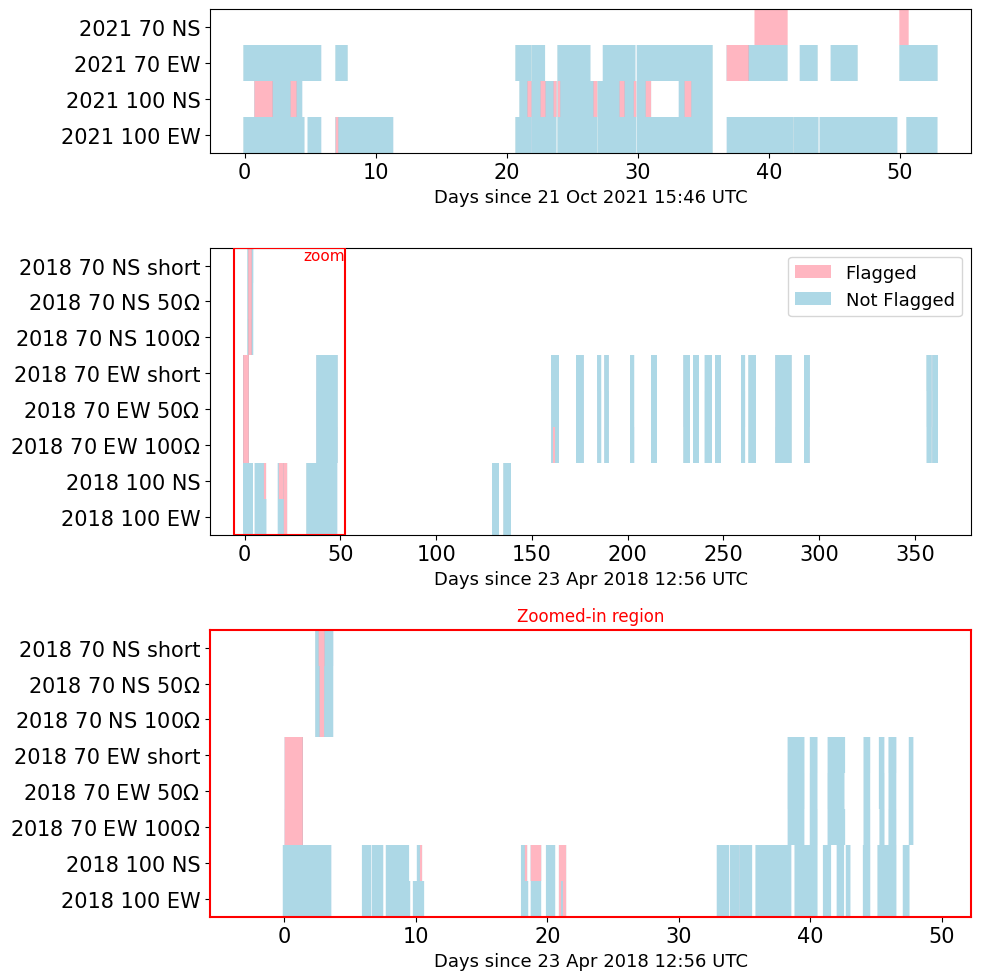

In [153]:
def to_days_since_ref(unix_array, reference):
    return (np.array(unix_array) - reference) / 86400.0  # seconds to days

ref2021_unix = np.min(systimeshort_meas_2021_100_EW)
ref2018_unix = np.min(systimeshort_meas_2018_100_EW)
ref2021 = datetime.fromtimestamp(ref2021_unix, tz=timezone.utc)
ref2018 = datetime.fromtimestamp(ref2018_unix, tz=timezone.utc)
print(ref2021,ref2018)

'''Version with zoomed in box'''
# Comparing times of flagged spectra
systf_2021_70_NS = systimeshort_meas_2021_70_NS # all flagged
print('2021_70_NS',len(systf_2021_70_NS)/len(systimeshort_meas_2021_70_NS)*100,'%')
systf_2021_70_EW = systimeshort_meas_2021_70_EW[res_datashort_2021_70_EW[:,minfreqarg] >= 0.15]
print('2021_70_EW',len(systf_2021_70_EW)/len(systimeshort_meas_2021_70_EW)*100,'%')
systf_2021_100_NS = systimeshort_meas_2021_100_NS[res_datashort_2021_100_NS[:,maxfreqarg] >= 0.03]
print('2021_100_NS',len(systf_2021_100_NS)/len(systimeshort_meas_2021_100_NS)*100,'%')
systf_2021_100_EW = systimeshort_meas_2021_100_EW[res_datashort_2021_100_EW[:,maxfreqarg] >= 0.15]
print('2021_100_EW',len(systf_2021_100_EW)/len(systimeshort_meas_2021_100_EW)*100,'%')

systf_2018_70_NS_short = systimeshort_meas_2018_70_NS[res_datashort_2018_70_NS[:,minfreqarg] >= 0.015]
print('2018_70_NS_short',len(systf_2018_70_NS_short)/len(systimeshort_meas_2018_70_NS)*100,'%')
systf_2018_70_NS_res50 = systimeres50_meas_2018_70_NS[res_datares50_2018_70_NS[:,minfreqarg] >= 0.019]
print('2018_70_NS_res50',len(systf_2018_70_NS_res50)/len(systimeres50_meas_2018_70_NS)*100,'%')
systf_2018_70_NS_res100 = systimeres100_meas_2018_70_NS[res_datares100_2018_70_NS[:,minfreqarg] >= 0.022]
print('2018_70_NS_res100',len(systf_2018_70_NS_res100)/len(systimeres100_meas_2018_70_NS)*100,'%')


systf_2018_70_EW_short = systimeshort_meas_2018_70_EW[res_datashort_2018_70_EW[:,maxfreqarg] >= 0.03]
print('2018_70_EW_short',len(systf_2018_70_EW_short)/len(systimeshort_meas_2018_70_EW)*100,'%')
systf_2018_70_EW_res50 = systimeres50_meas_2018_70_EW[res_datares50_2018_70_EW[:,int(100/freqstep)] >= 0.03]
print('2018_70_EW_res50',len(systf_2018_70_EW_res50)/len(systimeres50_meas_2018_70_EW)*100,'%')
systf_2018_70_EW_res100 = systimeres100_meas_2018_70_EW[res_datares100_2018_70_EW[:,minfreqarg] >= 0.03]
print('2018_70_EW_res100',len(systf_2018_70_EW_res100)/len(systimeres100_meas_2018_70_EW)*100,'%')


systf_2018_100_NS = systimeshort_meas_2018_100_NS[res_datashort_2018_100_NS[:,maxfreqarg] >= 0.09]
print('2018_100_NS',len(systf_2018_100_NS)/len(systimeshort_meas_2018_100_NS)*100,'%')
systf_2018_100_EW = systimeshort_meas_2018_100_EW[res_datashort_2018_100_EW[:,maxfreqarg] >= 0.05]
print('2018_100_EW',len(systf_2018_100_EW)/len(systimeshort_meas_2018_100_EW)*100,'%')


# import matplotlib.dates as mdates
# from datetime import datetime, timezone
# Plot the times
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(10,10),gridspec_kw={'height_ratios': [1, 2, 2]})
# plt.figure(figsize=(10,4))

# ------- ALL DATA ---------------------- #
# 2021 70 NS
ax[0].vlines(to_days_since_ref(systimeshort_meas_2021_70_NS,ref2021_unix),color='lightblue',ymin=6.5,ymax=6) # in UNIX
# 2021 70 EW
ax[0].vlines(to_days_since_ref(systimeshort_meas_2021_70_EW,ref2021_unix),color='lightblue',ymin=5,ymax=5.5) # in UNIX
# plt.axvline(systimeshort_meas_2021_70_EW[i]),color='lightblue',ymin=0,ymax=0.5) # in UTC
# 2021 100 NS
ax[0].vlines(to_days_since_ref(systimeshort_meas_2021_100_NS,ref2021_unix),color='lightblue',ymin=4.5,ymax=5) # in UNIX
# 2021 100 EW
ax[0].vlines(to_days_since_ref(systimeshort_meas_2021_100_EW,ref2021_unix),color='lightblue',ymin=4,ymax=4.5) # in UNIX
# 2018 70 NS SHORT
ax[1].vlines(to_days_since_ref(systimeshort_meas_2018_70_NS,ref2018_unix),color='lightblue',ymin=3.5,ymax=4) # in UNIX
# 2018 70 NS RES50
ax[1].vlines(to_days_since_ref(systimeres50_meas_2018_70_NS,ref2018_unix),color='lightblue',ymin=3,ymax=3.5) # in UNIX
# 2018 70 NS RES100
ax[1].vlines(to_days_since_ref(systimeres100_meas_2018_70_NS,ref2018_unix),color='lightblue',ymin=2.5,ymax=3) # in UNIX
# 2018 70 EW SHORT
ax[1].vlines(to_days_since_ref(systimeshort_meas_2018_70_EW,ref2018_unix),color='lightblue',ymin=2,ymax=2.5) # in UNIX
# 2018 70 EW RES50
ax[1].vlines(to_days_since_ref(systimeres50_meas_2018_70_EW,ref2018_unix),color='lightblue',ymin=1.5,ymax=2) # in UNIX
# 2018 70 EW RES100
ax[1].vlines(to_days_since_ref(systimeres100_meas_2018_70_EW,ref2018_unix),color='lightblue',ymin=1,ymax=1.5) # in UNIX
# 2018 100 NS
ax[1].vlines(to_days_since_ref(systimeshort_meas_2018_100_NS,ref2018_unix),color='lightblue',ymin=0.5,ymax=1) # in UNIX
# 2018 100 EW
ax[1].vlines(to_days_since_ref(systimeshort_meas_2018_100_EW,ref2018_unix),color='lightblue',ymin=0,ymax=0.5) # in UNIX

'''Zoomed in plot'''
# 2018 70 NS SHORT
ax[2].vlines(to_days_since_ref(systimeshort_meas_2018_70_NS,ref2018_unix),color='lightblue',ymin=3.5,ymax=4) # in UNIX
# 2018 70 NS RES50
ax[2].vlines(to_days_since_ref(systimeres50_meas_2018_70_NS,ref2018_unix),color='lightblue',ymin=3,ymax=3.5) # in UNIX
# 2018 70 NS RES100
ax[2].vlines(to_days_since_ref(systimeres100_meas_2018_70_NS,ref2018_unix),color='lightblue',ymin=2.5,ymax=3) # in UNIX
# 2018 70 EW SHORT
ax[2].vlines(to_days_since_ref(systimeshort_meas_2018_70_EW,ref2018_unix),color='lightblue',ymin=2,ymax=2.5) # in UNIX
# 2018 70 EW RES50
ax[2].vlines(to_days_since_ref(systimeres50_meas_2018_70_EW,ref2018_unix),color='lightblue',ymin=1.5,ymax=2) # in UNIX
# 2018 70 EW RES100
ax[2].vlines(to_days_since_ref(systimeres100_meas_2018_70_EW,ref2018_unix),color='lightblue',ymin=1,ymax=1.5) # in UNIX
# 2018 100 NS
ax[2].vlines(to_days_since_ref(systimeshort_meas_2018_100_NS,ref2018_unix),color='lightblue',ymin=0.5,ymax=1) # in UNIX
# 2018 100 EW
ax[2].vlines(to_days_since_ref(systimeshort_meas_2018_100_EW,ref2018_unix),color='lightblue',ymin=0,ymax=0.5) # in UNIX

# ------- FLAGGED DATA ---------------- #
# 2021 70 NS
ax[0].vlines(to_days_since_ref(systf_2021_70_NS,ref2021_unix),color='lightpink',ymin=5.5,ymax=6) # in UNIX timestamp
# 2021 70 EW
# plt.axvline((systf_2021_70_EW[i]-systf_2021_70_EW[0])/3600,color='lightblue',ymin=0,ymax=0.5) # in hours
ax[0].vlines(to_days_since_ref(systf_2021_70_EW,ref2021_unix),color='lightpink',ymin=5,ymax=5.5) # in UNIX timestamp
# plt.axvline(datetime.fromtimestamp(systf_2021_70_EW[i], tz=timezone.utc),color='lightblue',ymin=0,ymax=0.5) # in UTC
# 2021 100 NS
ax[0].vlines(to_days_since_ref(systf_2021_100_NS,ref2021_unix),color='lightpink',ymin=4.5,ymax=5) # in UNIX
#2021 100 EW
# plt.axvline((systf_2021_100_EW[i]-systf_2021_70_EW[0])/3600,color='lightpink',ymin=0.5,ymax=1) # in hours
ax[0].vlines(to_days_since_ref(systf_2021_100_EW,ref2021_unix),color='lightpink',ymin=4,ymax=4.5) # in UNIX
# plt.axvline(datetime.fromtimestamp(systf_2021_100_EW[i], tz=timezone.utc),color='lightpink',ymin=0.5,ymax=1) # in UTC
# 2018 70 NS SHORT
ax[1].vlines(to_days_since_ref(systf_2018_70_NS_short,ref2018_unix),color='lightpink',ymin=3.5,ymax=4) # in UNIX timestamp
# 2018 70 NS RES50
ax[1].vlines(to_days_since_ref(systf_2018_70_NS_res50,ref2018_unix),color='lightpink',ymin=3,ymax=3.5) # in UNIX timestamp
# 2018 70 NS RES100
ax[1].vlines(to_days_since_ref(systf_2018_70_NS_res100,ref2018_unix),color='lightpink',ymin=2.5,ymax=3) # in UNIX timestamp
# 2018 70 EW SHORT
ax[1].vlines(to_days_since_ref(systf_2018_70_EW_short,ref2018_unix),color='lightpink',ymin=2,ymax=2.5) # in UNIX timestamp
# 2018 70 EW RES50
ax[1].vlines(to_days_since_ref(systf_2018_70_EW_res50,ref2018_unix),color='lightpink',ymin=1.5,ymax=2) # in UNIX timestamp
# 2018 70 EW RES100
ax[1].vlines(to_days_since_ref(systf_2018_70_EW_res100,ref2018_unix),color='lightpink',ymin=1,ymax=1.5) # in UNIX timestamp
# 2018 100 NS
ax[1].vlines(to_days_since_ref(systf_2018_100_NS,ref2018_unix),color='lightpink',ymin=0.5,ymax=1) # in UNIX
#2018 100 EW
ax[1].vlines(to_days_since_ref(systf_2018_100_EW,ref2018_unix),color='lightpink',ymin=0,ymax=0.5) # in UNIX

'''Zoomed in plot'''
# 2018 70 NS SHORT
ax[2].vlines(to_days_since_ref(systf_2018_70_NS_short,ref2018_unix),color='lightpink',ymin=3.5,ymax=4) # in UNIX timestamp
# 2018 70 NS RES50
ax[2].vlines(to_days_since_ref(systf_2018_70_NS_res50,ref2018_unix),color='lightpink',ymin=3,ymax=3.5) # in UNIX timestamp
# 2018 70 NS RES100
ax[2].vlines(to_days_since_ref(systf_2018_70_NS_res100,ref2018_unix),color='lightpink',ymin=2.5,ymax=3) # in UNIX timestamp
# 2018 70 EW SHORT
ax[2].vlines(to_days_since_ref(systf_2018_70_EW_short,ref2018_unix),color='lightpink',ymin=2,ymax=2.5) # in UNIX timestamp
# 2018 70 EW RES50
ax[2].vlines(to_days_since_ref(systf_2018_70_EW_res50,ref2018_unix),color='lightpink',ymin=1.5,ymax=2) # in UNIX timestamp
# 2018 70 EW RES100
ax[2].vlines(to_days_since_ref(systf_2018_70_EW_res100,ref2018_unix),color='lightpink',ymin=1,ymax=1.5) # in UNIX timestamp
# 2018 100 NS
ax[2].vlines(to_days_since_ref(systf_2018_100_NS,ref2018_unix),color='lightpink',ymin=0.5,ymax=1) # in UNIX
#2018 100 EW
ax[2].vlines(to_days_since_ref(systf_2018_100_EW,ref2018_unix),color='lightpink',ymin=0,ymax=0.5) # in UNIX

# 2021 plot
custom_tick_positions = [4.25,4.75,5.25,5.75]
custom_tick_labels = ['2021 100 EW','2021 100 NS','2021 70 EW','2021 70 NS']
ax[0].set_ylim(4, 6)
ax[0].set_yticks(custom_tick_positions)
ax[0].set_yticklabels(custom_tick_labels)
# ax[0].set_xlabel('UNIX Timestamp [s]')
ax[0].set_xlabel(f'Days since {ref2021.strftime("%d %b %Y %H:%M UTC")}')

plt.subplots_adjust(hspace=0.5)

# 2018 plot
custom_tick_positions = [0.25, 0.75, 1.25, 1.75, 2.25, 2.75,3.25, 3.75]
# custom_tick_labels = ['2018 100 EW','2018 100 NS','2018 70 EW','2018 70 NS $100\Omega$','2018 70 NS $50\Omega$','2018 70 NS short']
# custom_tick_labels = ['2018 70 EW res100','2018 70 EW res50','2018 70 EW short','2018 70 NS $100\Omega$','2018 70 NS $50\Omega$','2018 70 NS short']
custom_tick_labels = ['2018 100 EW','2018 100 NS','2018 70 EW $100\Omega$','2018 70 EW $50\Omega$','2018 70 EW short','2018 70 NS $100\Omega$','2018 70 NS $50\Omega$','2018 70 NS short']
ax[1].set_ylim(0, 4)
ax[1].set_yticks(custom_tick_positions)
ax[1].set_yticklabels(custom_tick_labels)
# ax[1].set_xlabel('UNIX Timestamp [s]')
ax[1].set_xlabel(f'Days since {ref2018.strftime("%d %b %Y %H:%M UTC")}')
# ax[1].set_xlim(left=1.524e9,right=1.525e9)

# Zoomed in box
zoom_start = to_days_since_ref(1.524e9,ref2018_unix)
zoom_end = to_days_since_ref(1.529e9,ref2018_unix)
zoom_ylim = (0,3.99)

ax[2].set_xlim(zoom_start, zoom_end)
ax[2].set_ylim(0,4)
ax[2].set_yticks(custom_tick_positions)
ax[2].set_yticklabels(custom_tick_labels)
# ax[2].set_xlabel('UNIX Timestamp [s]')
ax[2].set_xlabel(f'Days since {ref2018.strftime("%d %b %Y %H:%M UTC")}')
ax[2].set_title("Zoomed-in region",fontsize=12,color='red')

from matplotlib.patches import Patch, Rectangle
# Add rectangle to ax2 to indicate zoomed-in area
highlight_rect = Rectangle(
    (zoom_start, zoom_ylim[0]),                    # (x0, y0)
    width=zoom_end - zoom_start,                   # width in datetime
    height=zoom_ylim[1] - zoom_ylim[0],            # height
    linewidth=1.5,
    edgecolor='red',
    facecolor='none',
    linestyle='-',
    zorder=100 # in front of everything else
)
ax[1].add_patch(highlight_rect)

# Match zoomed-in subplot outline to box color
for spine in ax[2].spines.values():
    spine.set_edgecolor('red')
    spine.set_linewidth(1.5)

# Coordinates for top-right corner of the rectangle
label_x = zoom_end
label_y = zoom_ylim[1]

# Add "zoom" text inside the rectangle
ax[1].text(
    label_x, label_y, 'zoom',
    color='red',
    fontsize=11,
    ha='right', va='top',
    zorder=101  # ensure it sits above the rectangle
)

# Create custom legend handles
# from matplotlib.patches import Patch
custom_handles = [
    Patch(facecolor='lightpink', edgecolor='None', label='Flagged'),
    Patch(facecolor='lightblue', edgecolor='None', label='Not Flagged')
]
# Add legend
ax[1].legend(handles=custom_handles)
plt.tight_layout()
# plt.subplots_adjust(right=0.8)  # Give room for legend
plt.savefig('flagging-summary-plot-zoombox-days.jpg',dpi=300,bbox_inches='tight')
plt.show()

## Under Development

In [ ]:
''' Example code for coloring the odd spectra a different color'''
# if res_splitshort[n_day][i,minfreqarg]>0.15: 
#     print('day',n_day,'LST',lst_splitshort[n_day][i],'LSTi',i) # printing out which spectra constitute the weird one
#     plt.plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='orange',alpha=0.05)
# else:
#     plt.plot(freqarr[minfreqarg:maxfreqarg],res_splitshort[n_day][i,minfreqarg:maxfreqarg],color='grey',alpha=0.05)